# Analyse Comparative des Résidus — Méthodes Spatiotemporelles SAR Sentinel-1

Ce notebook regroupe l'analyse des résidus des **trois méthodes de modélisation** appliquées aux séries temporelles SAR de rétrodiffusion sur forêts tropicales (Paracou / Trinité) :

1. **Spline pénalisée** — régression à l'échelle régionale puis locale, paramètres transférés (λ, n_knots)
2. **STL** — décomposition LOESS (Trend + Seasonal + Residual)
3. **Fourier local contraint** — fréquences extraites sur le régional via Welch, ajustement local par moindres carrés

Pour chaque méthode, on analyse les résidus à **deux échelles** :
- **Régionale** (allROI — grande emprise, peu de bruit)
- **Locale** (TropiScat / Trinité — emprise réduite, plus de bruit)

L'analyse des résidus comprend : histogramme + densité gaussienne, Q-Q plot, ACF (Ljung-Box), tests de Shapiro-Wilk, et un tableau récapitulatif comparatif final.

## 1. Imports

In [15]:
import csv
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd
import os

from scipy.optimize import curve_fit
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL
from scipy.interpolate import BSpline
import seaborn as sns

import importlib
import function
importlib.reload(function)
from function import *

sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 13, "axes.titlesize": 14, "legend.fontsize": 12})

os.makedirs("figures_residuals", exist_ok=True)
os.makedirs("figures_spline",    exist_ok=True)
os.makedirs("figures_stl",       exist_ok=True)
os.makedirs("figures_fourier",   exist_ok=True)

print("✓ Imports OK")

✓ Imports OK


## 2. Paramètres globaux

Modifier **uniquement** cette cellule pour changer la série ou les hyperparamètres.

In [16]:
# ════════════════════════════════════════════════════════════
#  PARAMÈTRES — à modifier ici uniquement
# ════════════════════════════════════════════════════════════

SERIES      = "VV_ASC"   # "VV_ASC" | "VH_ASC" | "VV_DSC" | "VH_DSC"
ROI_IDX     = 0           # index de la ROI pour les séries régionales
ALPHA_CP    = 3.0         # Mallows Cp : 3=Kooperberg, 2=AIC, log(n)=BIC
STL_PERIOD  = 30          # nb d'acquisitions par cycle annuel (≈ 365/12 j)
N_FREQ_LIST = [2, 3, 4]   # modes harmoniques Fourier à tester

print(f"Série        : {SERIES}")
print(f"ROI index    : {ROI_IDX}")
print(f"Alpha Cp     : {ALPHA_CP}")
print(f"STL period   : {STL_PERIOD}")
print(f"Fourier n    : {N_FREQ_LIST}")

Série        : VV_ASC
ROI index    : 0
Alpha Cp     : 3.0
STL period   : 30
Fourier n    : [2, 3, 4]


## 3. Chargement des données

In [17]:
# ── Données régionales : Paracou allROI ──────────────────────────────────────
value_reg, date_reg, _ = prepadataframe(Paracou=1, allROI=1)

dates_reg    = pd.to_datetime(date_reg[SERIES])
values_array = value_reg[SERIES]
if values_array.ndim == 1:
    values_array = values_array[:, np.newaxis]
roi_r      = min(ROI_IDX, values_array.shape[1] - 1)
values_reg = values_array[:, roi_r]

# Retrait de l'outlier connu sur les séries ASC (index 208)
if SERIES in ["VV_ASC", "VH_ASC"] and len(values_reg) > 209:
    mask_r     = np.ones(len(values_reg), dtype=bool)
    mask_r[208] = False
    values_reg = values_reg[mask_r]
    dates_reg  = dates_reg[mask_r]

t_reg = np.array([(d - dates_reg[0]).days for d in dates_reg], dtype=float)

print(f"Régional : {len(values_reg)} pts  ({dates_reg[0].date()} → {dates_reg[-1].date()})")

# ── Données locales : Paracou TropiScat ──────────────────────────────────────
value_loc, date_loc, _ = prepadataframe(Paracou=1, allROI=0)

dates_loc    = pd.to_datetime(date_loc[SERIES])
values_arr_l = value_loc[SERIES]
if values_arr_l.ndim == 1:
    values_arr_l = values_arr_l[:, np.newaxis]
roi_l      = min(ROI_IDX, values_arr_l.shape[1] - 1)
values_loc = values_arr_l[:, roi_l]

if SERIES in ["VV_ASC", "VH_ASC"] and len(values_loc) > 209:
    mask_l      = np.ones(len(values_loc), dtype=bool)
    mask_l[208] = False
    values_loc  = values_loc[mask_l]
    dates_loc   = dates_loc[mask_l]

t_loc = np.array([(d - dates_loc[0]).days for d in dates_loc], dtype=float)

print(f"Local    : {len(values_loc)} pts  ({dates_loc[0].date()} → {dates_loc[-1].date()})")

# ── Données locales : Trinité (défoliée) pour comparaison ────────────────────
val_masked_trin, val_unmasked_trin, date_trin, _ = prepadataframe(Paracou=0, allROI=0)

values_trinite = val_masked_trin["VV_DEFOL"]   # série défoliée
dates_trinite  = pd.to_datetime(date_trin["VV_DEFOL"])
t_trin         = np.array([(d - dates_trinite[0]).days for d in dates_trinite], dtype=float)

print(f"Trinité  : {len(values_trinite)} pts  ({dates_trinite[0].date()} → {dates_trinite[-1].date()})")

Régional : 242 pts  (2017-01-01 → 2025-10-22)
Local    : 242 pts  (2017-01-01 → 2025-10-22)
Trinité  : 262 pts  (2017-01-06 → 2025-10-15)


---
## 4. Méthode 1 — Spline pénalisée

### Rappel théorique

Le modèle est : $s(t) = \sum_{j=1}^{K} \beta_j B_j(t)$

Critère pénalisé : $\hat{\beta} = \arg\min_{\beta} \left[(Y - B\beta)^T(Y - B\beta) + \lambda \beta^T P \beta\right]$

**Pipeline :**
1. Sélection de $J$ (n_knots) par critère de Mallows $C_p$ sur le **régional**
2. Optimisation de $\lambda$ par GCV sur le **régional**
3. Régression régionale → résidus régionaux
4. Transfert de $\lambda$ au **local** : $\lambda_{\text{loc}} = \left(\frac{\sigma_{\text{loc}}}{\sigma_{\text{reg}}}\right)^2 \lambda_{\text{reg}}$
5. Régression locale → résidus locaux

### 4.1 Sélection du nombre de nœuds (Mallows $C_p$) — Régional

Série : VV_ASC  |  ROI index : 0  |  n = 242
Sélection du nombre de nœuds (alpha=3.0) ...

   # nœuds   p=nœuds+4             RSS              Cp
  ------------------------------------------------------
        80          84          5.8731         15.2402  ← modèle initial
        79          83          6.0235         15.2792
        78          82          5.9391         15.0833  ← optimal
        77          81          5.9741         15.0067  ← optimal
        76          80          6.0050         14.9261  ← optimal
        75          79          6.0262         14.8357  ← optimal
        74          78          5.9597         14.6578  ← optimal
        73          77          5.9869         14.5735  ← optimal
        72          76          6.0299         14.5050  ← optimal
        71          75          6.0634         14.4269  ← optimal
        70          74          5.9678         14.2198  ← optimal
        69          73          6.1236         14.2641
        68          

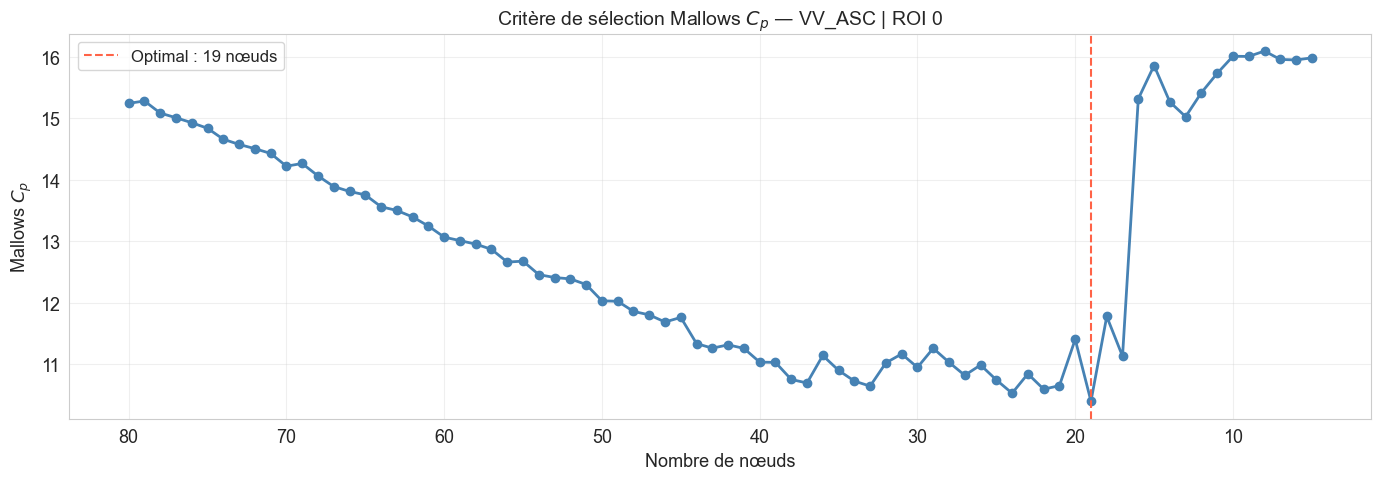


→ n_knots optimal = 19


In [18]:
# ── Sélection n_knots optimal sur le régional (Kooperberg & Stone) ───────────
print(f"Série : {SERIES}  |  ROI index : {roi_r}  |  n = {len(values_reg)}")
print(f"Sélection du nombre de nœuds (alpha={ALPHA_CP}) ...\n")

n_knots_optimal, history = stepwise_knot_selection_bspline(
    t_reg, values_reg, alpha=ALPHA_CP, verbose=True
)

# Visualisation du critère Cp
plt.figure(figsize=(14, 5))
plt.plot(history["n_knots"], history["Cp"], "o-", color="steelblue", linewidth=2)
plt.axvline(n_knots_optimal, color="tomato", linestyle="--",
            label=f"Optimal : {n_knots_optimal} nœuds")
plt.xlabel("Nombre de nœuds")
plt.ylabel("Mallows $C_p$")
plt.title(f"Critère de sélection Mallows $C_p$ — {SERIES} | ROI {roi_r}")
plt.gca().invert_xaxis()
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"figures_spline/mallows_cp_{SERIES}.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n→ n_knots optimal = {n_knots_optimal}")

### 4.2 Ajustement spline pénalisée — Échelle régionale

λ_reg = 1.9630e-03  |  n_knots = 19


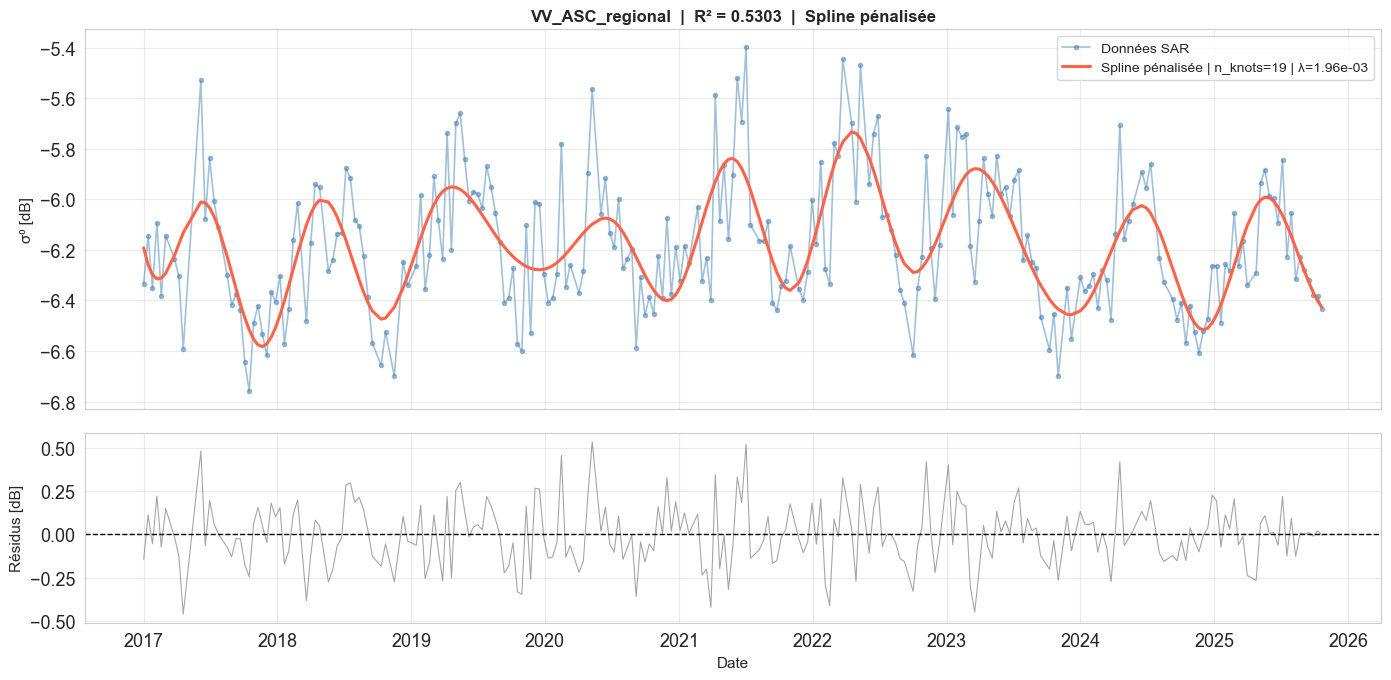

    → spline_fit_VV_ASC_regional_k19.png
R² régional = 0.5303


In [19]:
# ── Ajustement spline régional ────────────────────────────────────────────────
B_reg    = build_bspline_basis(t_reg, n_knots_optimal)  #= build_bspline_basis(t_reg, len(values_reg))
lam_reg  = optimize_lambda_gcv(B_reg, values_reg)
_, Y_hat_reg = penalized_spline_fit(B_reg, values_reg, lam_reg)

print(f"λ_reg = {lam_reg:.4e}  |  n_knots = {n_knots_optimal}")   # n_knots = {len(values_reg)}")   

# Visualisation + extraction des résidus régionaux
residuals_spline_reg, r2_spline_reg = plot_spline_fit(
    t_reg, values_reg, Y_hat_reg, dates_reg,
    nom=f"{SERIES}_regional",
    n_knots=n_knots_optimal,   # n_knots=len(values_reg),      
    lam=lam_reg
)
print(f"R² régional = {r2_spline_reg:.4f}")

### 4.3 Analyse des résidus — Spline régionale

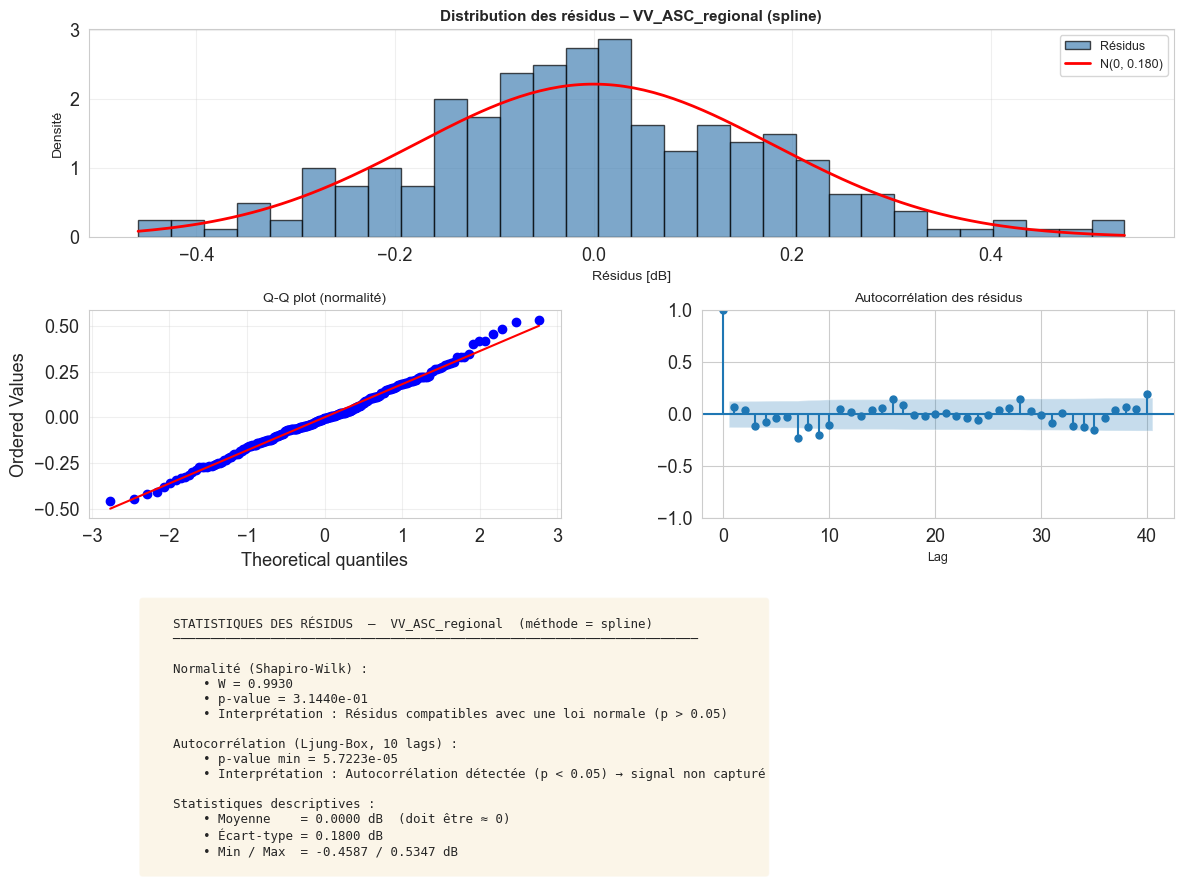

    → residuals_analysis_VV_ASC_regional_méthodespline.png


In [20]:
analyze_residuals(residuals_spline_reg, f"{SERIES}_regional", method="spline")

### 4.4 Transfert des paramètres et ajustement local

σ_reg         = 0.2626 dB
σ_loc         = 0.6444 dB
σ_loc / σ_reg = 2.4540
λ_reg         = 1.9630e-03
λ_loc         = (σ_loc/σ_reg)² × λ_reg = 1.1822e-02


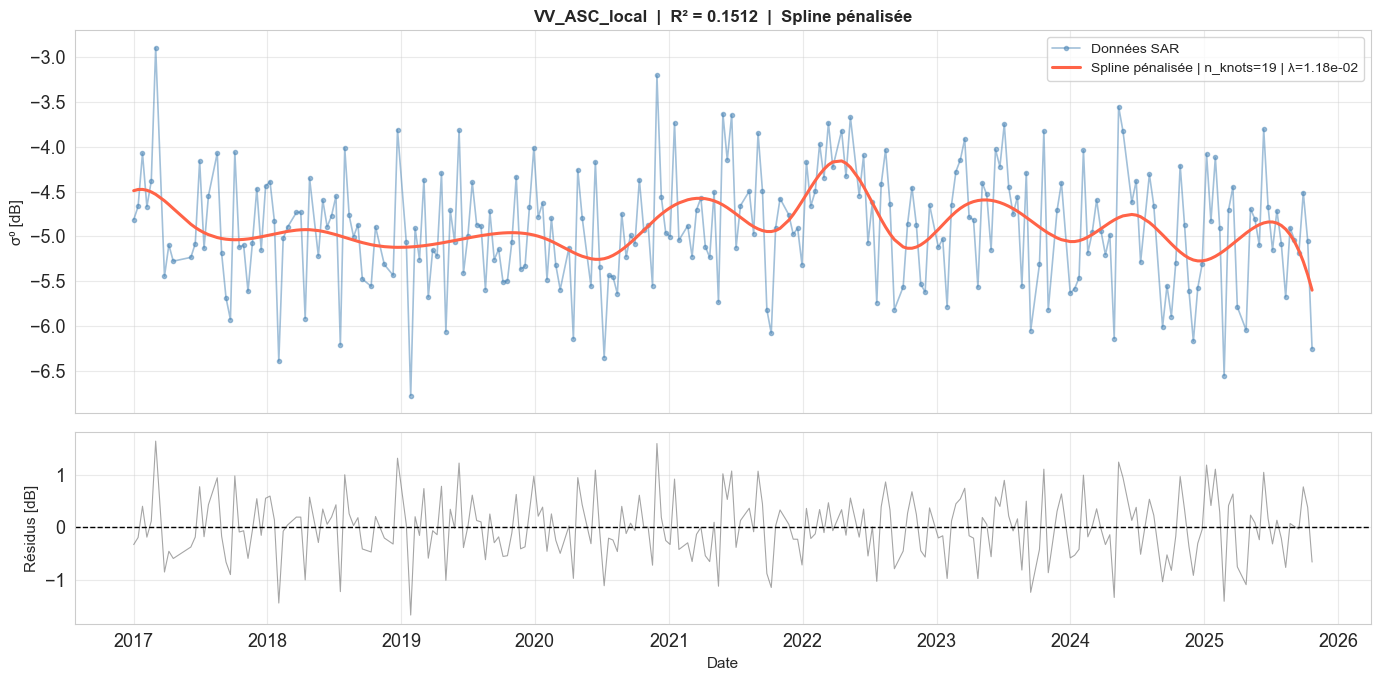

    → spline_fit_VV_ASC_local_k19.png
R² local = 0.1512


In [21]:
# ── Transfert de λ : régional → local ────────────────────────────────────────
B_loc    = build_bspline_basis(t_loc, n_knots_optimal)   #= build_bspline_basis(t_loc, len(values_reg))  

std_reg = np.std(values_reg)
std_loc = np.std(values_loc)
lam_loc = (std_loc / std_reg)**2 * lam_reg    # optimize_lambda_gcv(B_loc, values_loc)  

print(f"σ_reg         = {std_reg:.4f} dB")
print(f"σ_loc         = {std_loc:.4f} dB")
print(f"σ_loc / σ_reg = {std_loc / std_reg:.4f}")
print(f"λ_reg         = {lam_reg:.4e}")
print(f"λ_loc         = (σ_loc/σ_reg)² × λ_reg = {lam_loc:.4e}")

# ── Ajustement spline local avec λ transféré ──────────────────────────────────
_, Y_hat_loc = penalized_spline_fit(B_loc, values_loc, lam_loc)

residuals_spline_loc, r2_spline_loc = plot_spline_fit(
    t_loc, values_loc, Y_hat_loc, dates_loc,
    nom=f"{SERIES}_local",
    n_knots=n_knots_optimal,   # n_knots=len(values_reg),   
    lam=lam_loc
)
print(f"R² local = {r2_spline_loc:.4f}")

### 4.5 Analyse des résidus — Spline locale

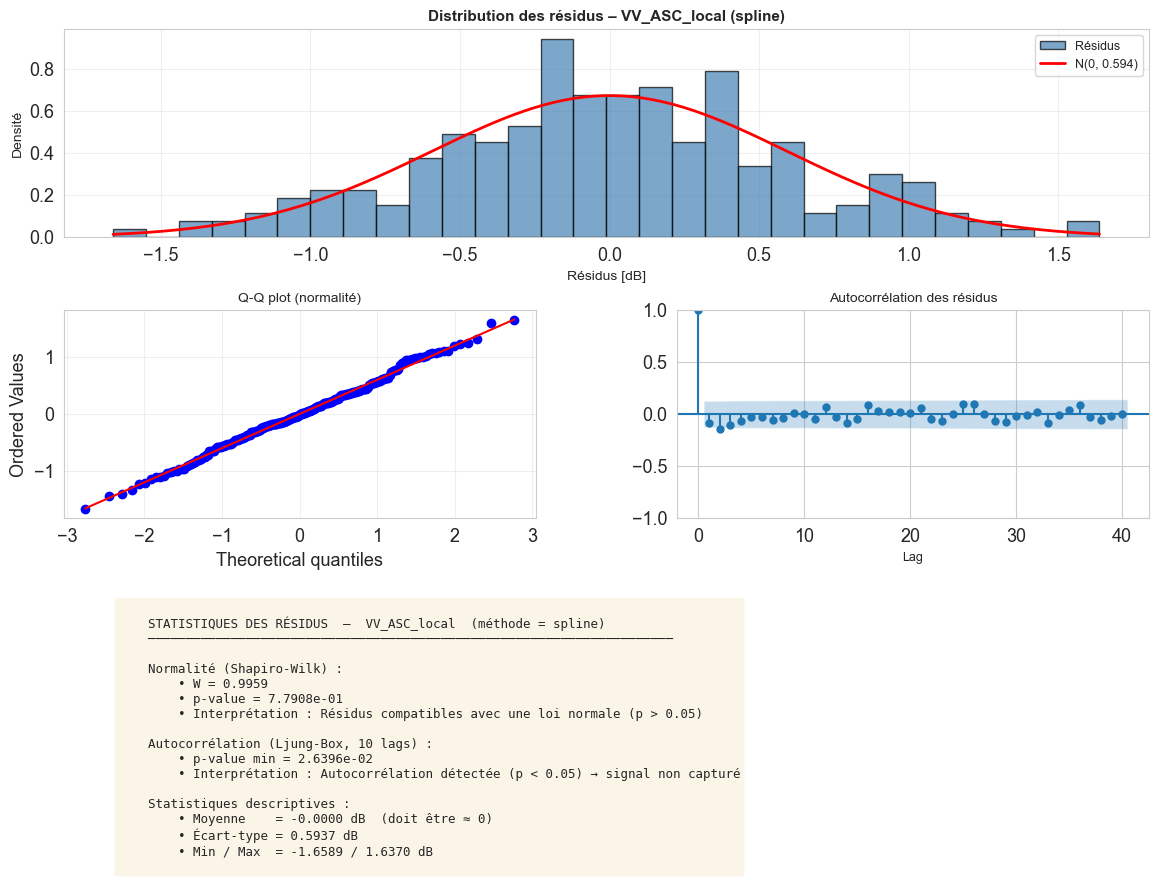

    → residuals_analysis_VV_ASC_local_méthodespline.png


In [22]:
analyze_residuals(residuals_spline_loc, f"{SERIES}_local", method="spline")

---
## 5. Méthode 2 — Décomposition STL

**STL** (Seasonal and Trend decomposition using LOESS) décompose :

$$y(t) = \text{Trend}(t) + \text{Seasonal}(t) + \text{Resid}(t)$$

La reconstruction est $\hat{y} = \text{Trend} + \text{Seasonal}$, et les résidus sont $\varepsilon = y - \hat{y}$.

On applique STL aux deux échelles : **régionale** puis **locale**.

### 5.1 STL — Échelle régionale

Variance tendance     : 3.9%
Variance saisonnalité : 43.8%
Variance résiduelle   : 52.6%


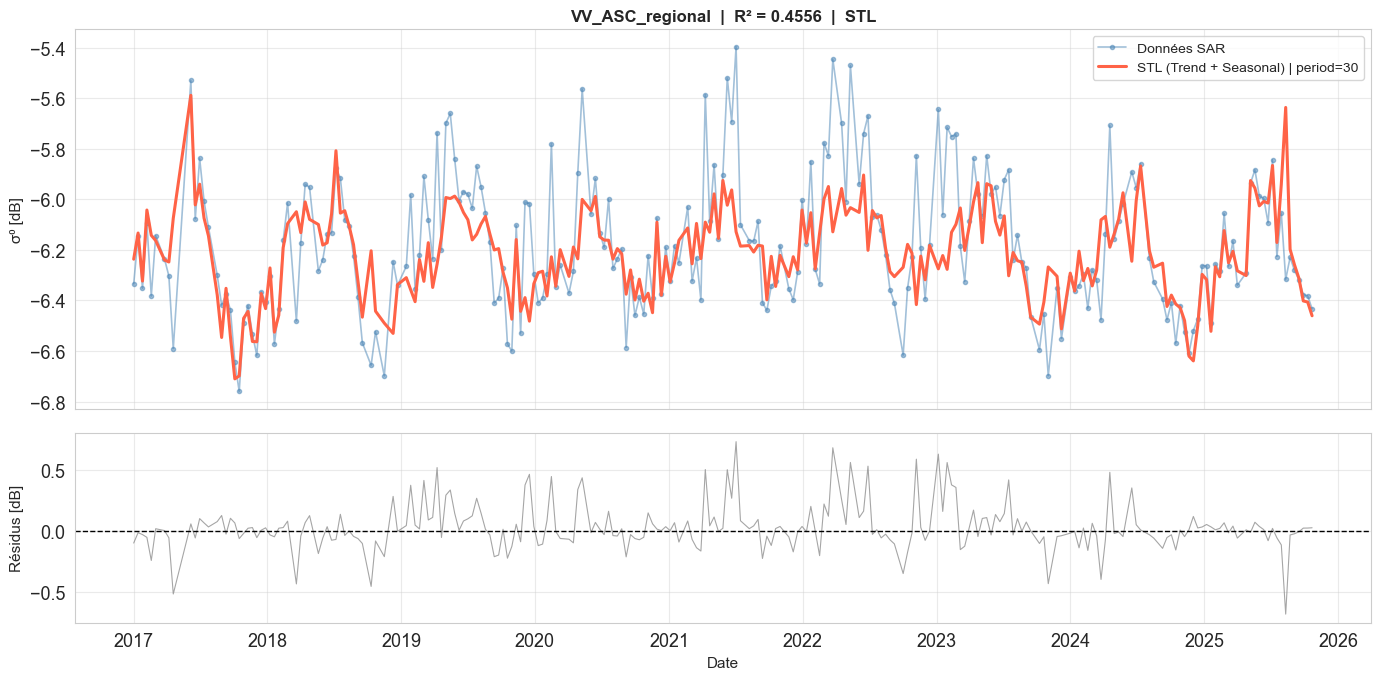

R² STL régional = 0.4556


In [23]:
# ── STL régional ─────────────────────────────────────────────────────────────
ts_reg = pd.Series(values_reg, index=dates_reg)

stl_reg    = STL(ts_reg, period=STL_PERIOD, robust=True)
res_reg    = stl_reg.fit()
trend_reg  = res_reg.trend.values
season_reg = res_reg.seasonal.values

var_tot_reg = ts_reg.var()
print(f"Variance tendance     : {np.var(trend_reg)  / var_tot_reg * 100:.1f}%")
print(f"Variance saisonnalité : {np.var(season_reg) / var_tot_reg * 100:.1f}%")
print(f"Variance résiduelle   : {np.var(res_reg.resid.values) / var_tot_reg * 100:.1f}%")

# Visualisation STL régional
Y_hat_stl_reg = trend_reg + season_reg
residuals_stl_reg = values_reg - Y_hat_stl_reg
ss_res = np.sum(residuals_stl_reg**2)
ss_tot = np.sum((values_reg - values_reg.mean())**2)
r2_stl_reg = 1 - ss_res / ss_tot

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
ax = axes[0]
ax.plot(dates_reg, values_reg, "-o", lw=1.2, alpha=0.5, markersize=3,
        label="Données SAR", color="steelblue")
ax.plot(dates_reg, Y_hat_stl_reg, "-", lw=2.2, color="tomato",
        label=f"STL (Trend + Seasonal) | period={STL_PERIOD}")
ax.set_ylabel("σ⁰ [dB]", fontsize=11)
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title(f"{SERIES}_regional  |  R² = {r2_stl_reg:.4f}  |  STL",
             fontsize=12, fontweight="bold")
ax = axes[1]
ax.plot(dates_reg, residuals_stl_reg, "-", lw=0.8, alpha=0.7, color="gray")
ax.axhline(0, color="black", linestyle="--", lw=1)
ax.set_ylabel("Résidus [dB]", fontsize=11)
ax.set_xlabel("Date", fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"figures_stl/stl_fit_{SERIES}_regional_p{STL_PERIOD}.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"R² STL régional = {r2_stl_reg:.4f}")

### 5.2 Analyse des résidus — STL régional

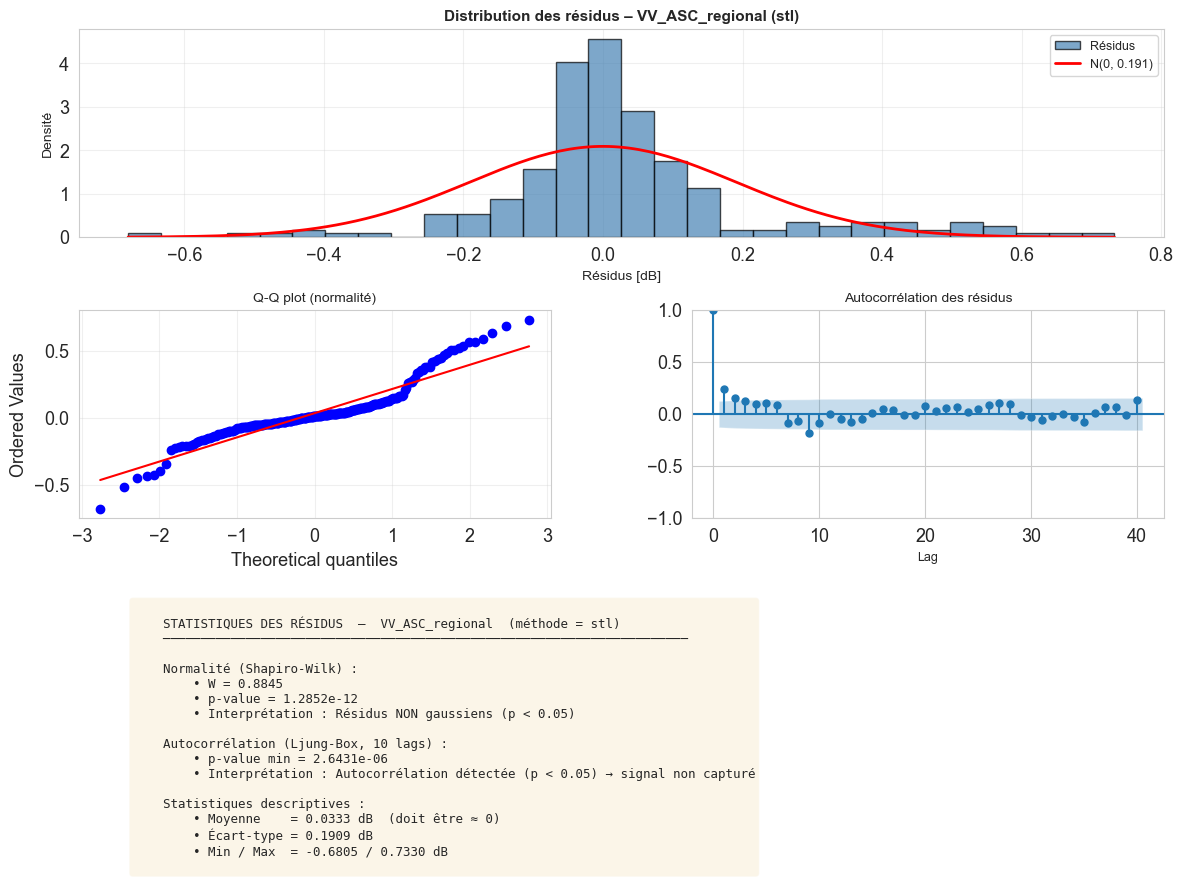

    → residuals_analysis_VV_ASC_regional_méthodestl.png


In [24]:
analyze_residuals(residuals_stl_reg, f"{SERIES}_regional", method="stl")

### 5.3 STL — Échelle locale

Variance tendance     : 7.0%
Variance saisonnalité : 43.6%
Variance résiduelle   : 67.2%


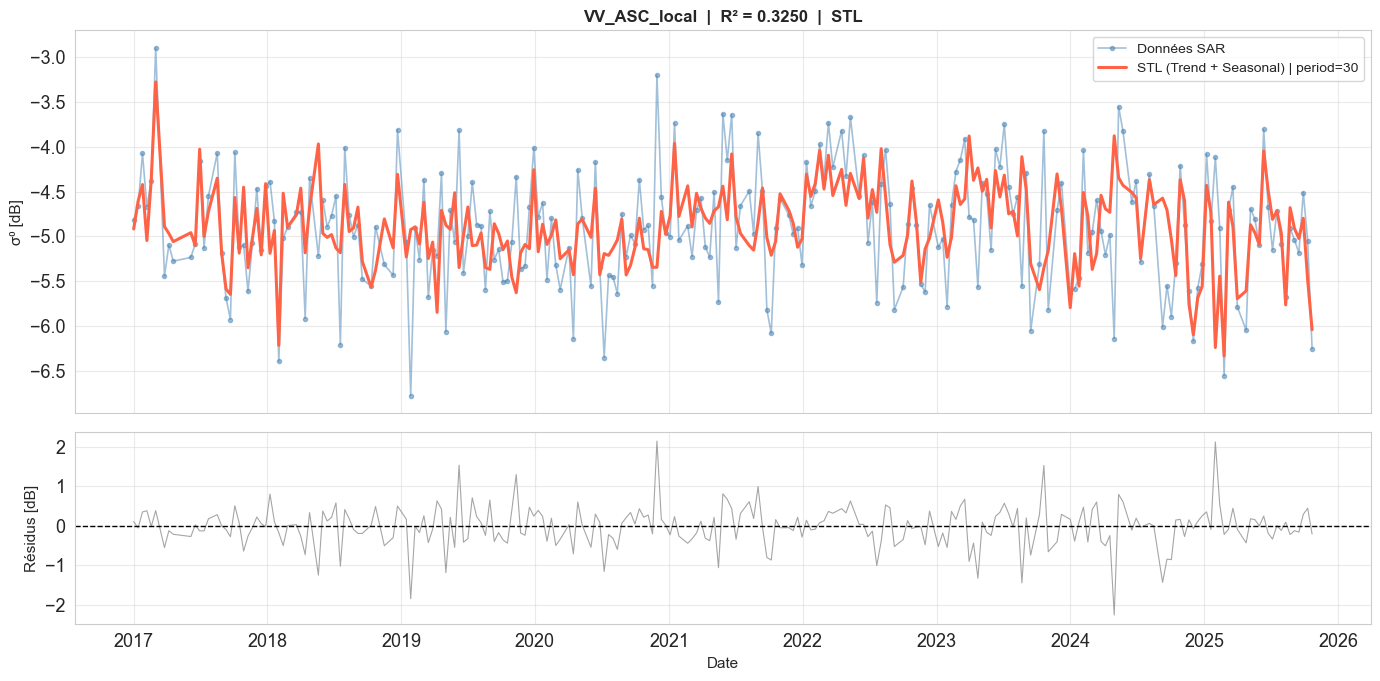

R² STL local = 0.3250


In [25]:
# ── STL local ─────────────────────────────────────────────────────────────────
ts_loc_s = pd.Series(values_loc, index=dates_loc)

stl_loc    = STL(ts_loc_s, period=STL_PERIOD, robust=True)
res_loc    = stl_loc.fit()
trend_loc  = res_loc.trend.values
season_loc = res_loc.seasonal.values

var_tot_loc = ts_loc_s.var()
print(f"Variance tendance     : {np.var(trend_loc)  / var_tot_loc * 100:.1f}%")
print(f"Variance saisonnalité : {np.var(season_loc) / var_tot_loc * 100:.1f}%")
print(f"Variance résiduelle   : {np.var(res_loc.resid.values) / var_tot_loc * 100:.1f}%")

Y_hat_stl_loc     = trend_loc + season_loc
residuals_stl_loc = values_loc - Y_hat_stl_loc
ss_res = np.sum(residuals_stl_loc**2)
ss_tot = np.sum((values_loc - values_loc.mean())**2)
r2_stl_loc = 1 - ss_res / ss_tot

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
ax = axes[0]
ax.plot(dates_loc, values_loc, "-o", lw=1.2, alpha=0.5, markersize=3,
        label="Données SAR", color="steelblue")
ax.plot(dates_loc, Y_hat_stl_loc, "-", lw=2.2, color="tomato",
        label=f"STL (Trend + Seasonal) | period={STL_PERIOD}")
ax.set_ylabel("σ⁰ [dB]", fontsize=11)
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title(f"{SERIES}_local  |  R² = {r2_stl_loc:.4f}  |  STL",
             fontsize=12, fontweight="bold")
ax = axes[1]
ax.plot(dates_loc, residuals_stl_loc, "-", lw=0.8, alpha=0.7, color="gray")
ax.axhline(0, color="black", linestyle="--", lw=1)
ax.set_ylabel("Résidus [dB]", fontsize=11)
ax.set_xlabel("Date", fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"figures_stl/stl_fit_{SERIES}_local_p{STL_PERIOD}.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"R² STL local = {r2_stl_loc:.4f}")

### 5.4 Analyse des résidus — STL local

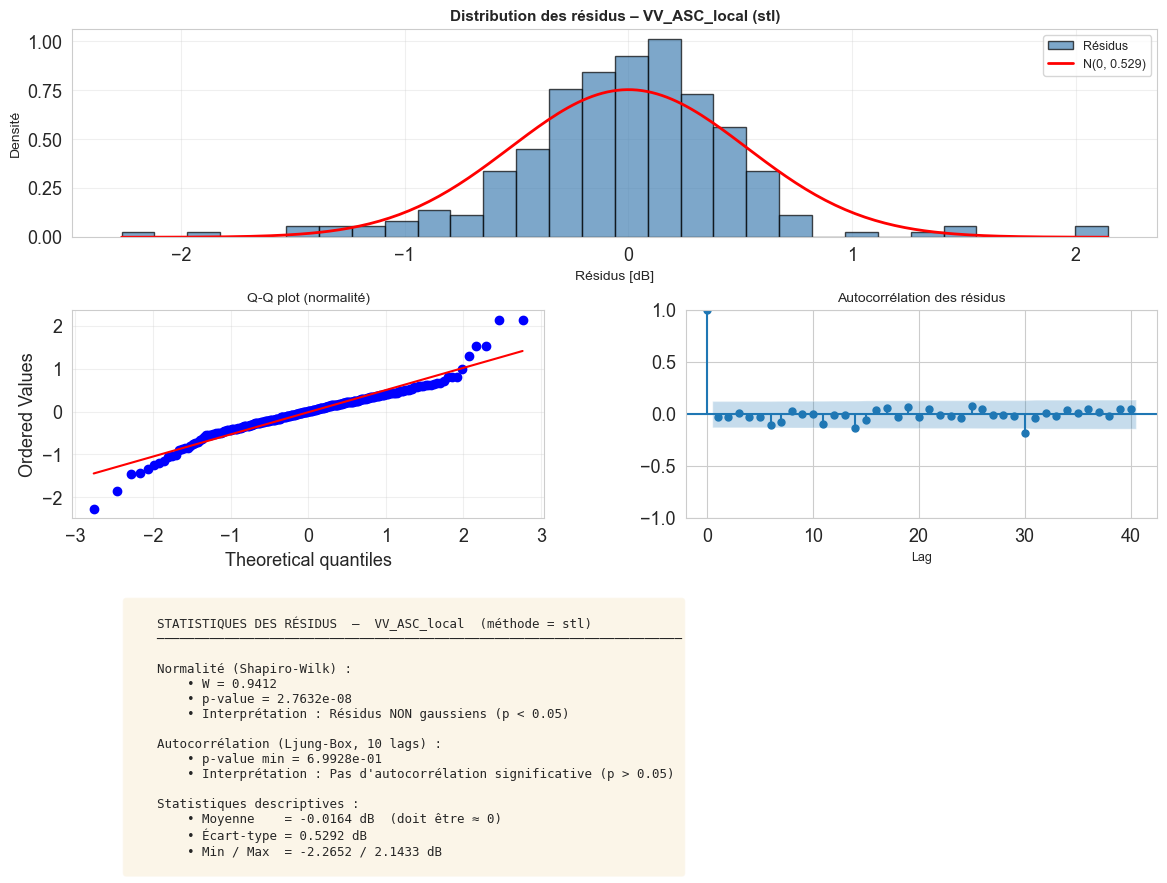

    → residuals_analysis_VV_ASC_local_méthodestl.png


In [26]:
analyze_residuals(residuals_stl_loc, f"{SERIES}_local", method="stl")

---
## 6. Méthode 3 — Série de Fourier locale contrainte par les paramètres régionaux

### Rappel théorique

$$\hat{y}(t) = a + bt + ct² + \sum_{i=1}^{n} \left[A_i \sin(\omega_i t) + B_i \cos(\omega_i t)\right]$$

où les fréquences $\omega_i$ sont **fixées** à partir de l'analyse spectrale (Welch) sur la série **régionale**.

**Pipeline :**
1. Analyse de Welch sur le **régional** → extraction des $n$ fréquences dominantes
2. Ajustement du modèle de Fourier sur le **régional** (fréquences fixes, amplitudes libres) → résidus régionaux
3. Réutilisation des **mêmes fréquences $\omega_i$** pour ajuster le modèle sur le **local** → résidus locaux
4. Test pour $n = 2, 3, 4$ modes

### 6.1 Extraction des fréquences dominantes — Régional (Welch)

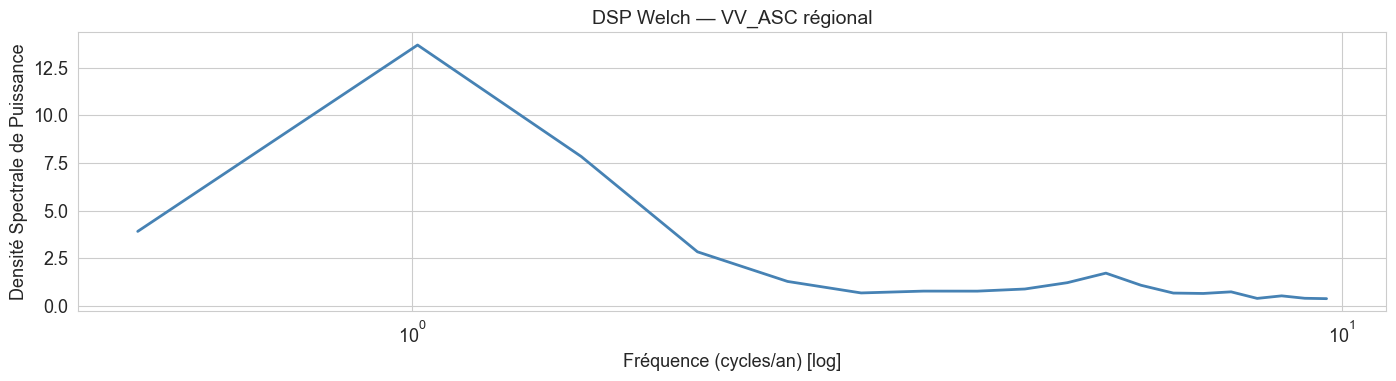

Fréquences dominantes extraites sur le régional :
  n=2 modes : périodes = ['360j', '240j'] (['0.99an', '0.66an'])
  n=3 modes : périodes = ['360j', '240j', '720j'] (['0.99an', '0.66an', '1.97an'])
  n=4 modes : périodes = ['360j', '240j', '720j', '180j'] (['0.99an', '0.66an', '1.97an', '0.49an'])


In [27]:
# ── Analyse de Welch sur le régional pour extraire les ω dominants ────────────
global omegas

fs_reg  = 1 / 12   # fréquence d'échantillonnage Sentinel-1 (~12 jours)
nperseg = min(int(730 / 12), len(values_reg))

freqs_w, psd_w = signal.welch(
    values_reg, fs=fs_reg, window="hann",
    nperseg=nperseg, noverlap=nperseg // 2,
    scaling="density"
)

# Visualisation du spectre de Welch régional
freqs_annee = freqs_w * 365
mask_plot   = (freqs_annee > 0.1) & (freqs_annee < 10)
plt.figure(figsize=(14, 4))
plt.semilogx(freqs_annee[mask_plot], psd_w[mask_plot], color="steelblue", lw=2)
plt.xlabel("Fréquence (cycles/an) [log]")
plt.ylabel("Densité Spectrale de Puissance")
plt.title(f"DSP Welch — {SERIES} régional")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"figures_fourier/welch_{SERIES}_regional.png", dpi=150, bbox_inches="tight")
plt.show()

print("Fréquences dominantes extraites sur le régional :")
for n_freq in N_FREQ_LIST:
    top_idx   = np.argsort(psd_w[1:])[::-1][:n_freq] + 1
    top_f     = freqs_w[top_idx]
    top_om    = 2 * np.pi * top_f
    top_per   = 2 * np.pi / top_om
    print(f"  n={n_freq} modes : périodes = {[f'{p:.0f}j' for p in top_per]} "
          f"({[f'{p/365:.2f}an' for p in top_per]})")

### 6.2 Ajustement Fourier — Régional puis Local (pour chaque n)

On boucle sur `N_FREQ_LIST = [2, 3, 4]`. À chaque itération :
- Les $\omega_i$ sont extraits sur le **régional**
- Le modèle est ajusté sur le **régional** → résidus régionaux
- Les **mêmes** $\omega_i$ sont utilisés pour ajuster le **local** → résidus locaux


  Fourier quadratique  n_freq = 2 modes
  Périodes : ['360j', '240j']
  → Ajustement régional ...
     Tendance : a=-6.3246, b=0.000239, c=-7.02e-08  (quadratique)


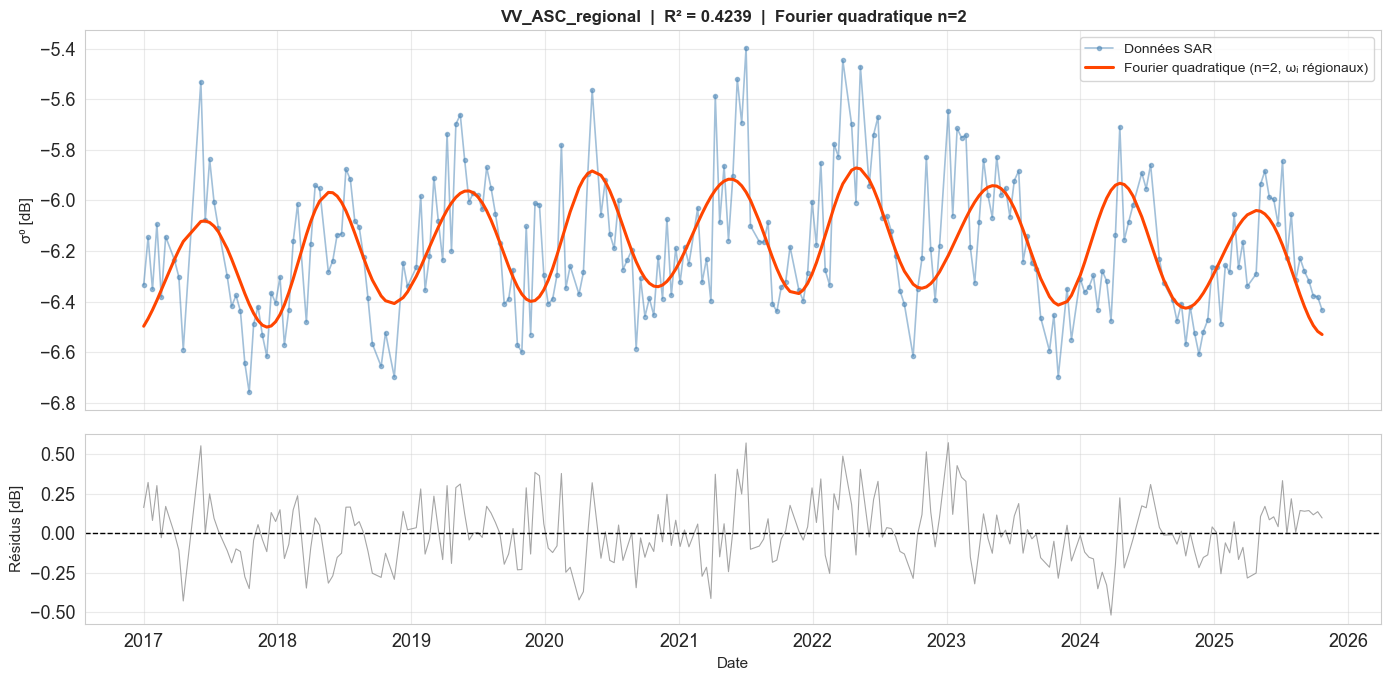

     R² = 0.4239  →  fourier_fit_VV_ASC_regional_n2.png
  → Analyse des résidus régionaux (n=2) ...


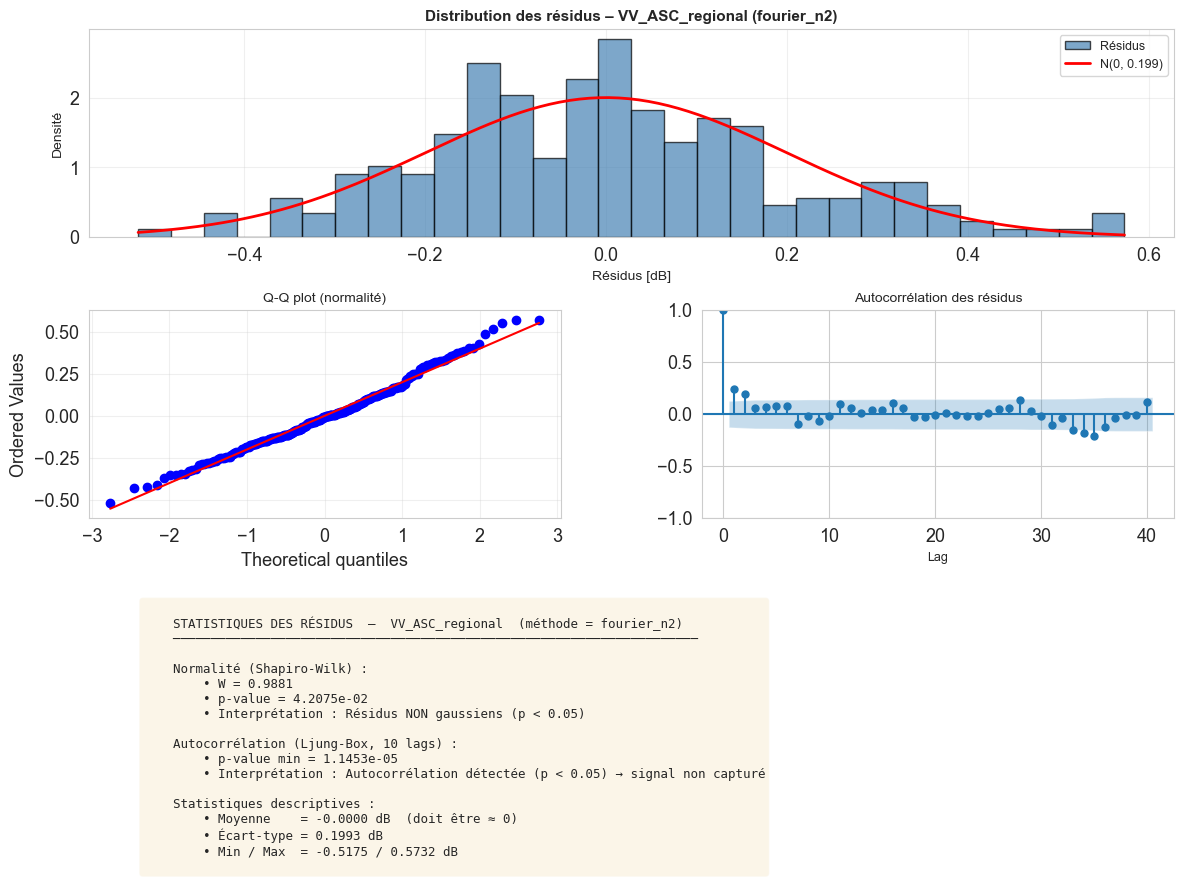

    → residuals_analysis_VV_ASC_regional_méthodefourier_n2.png
  → Ajustement local (ωᵢ régionaux fixés) ...
     Tendance : a=-5.0192, b=0.000217, c=-6.76e-08  (quadratique)


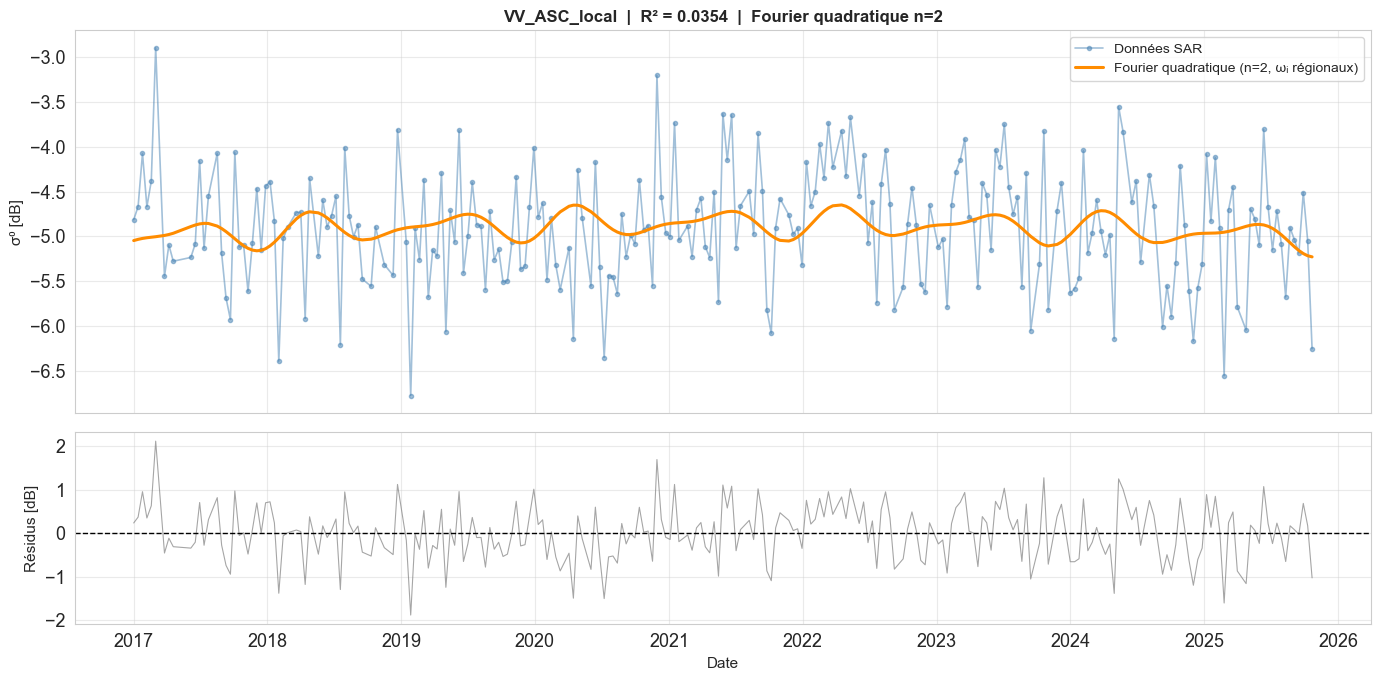

     R² = 0.0354  →  fourier_fit_VV_ASC_local_n2.png
  → Analyse des résidus locaux (n=2) ...


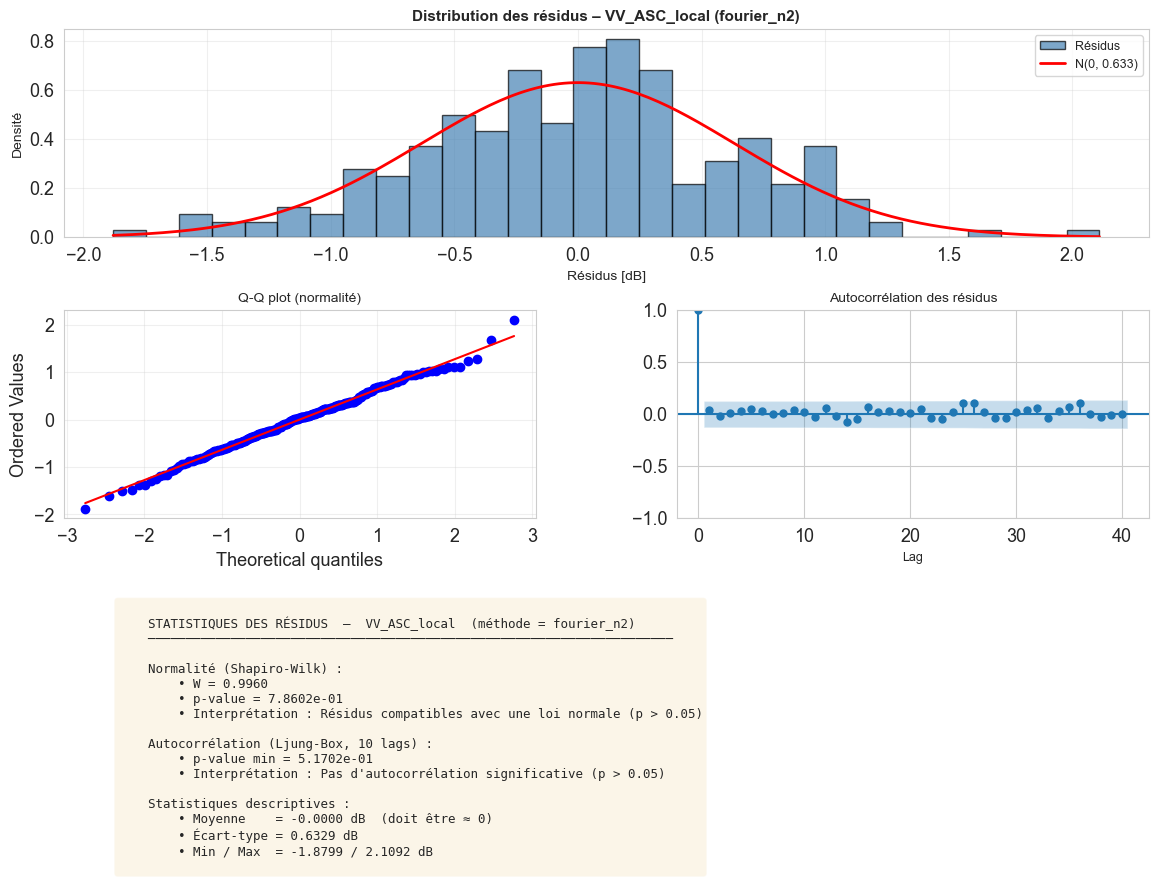

    → residuals_analysis_VV_ASC_local_méthodefourier_n2.png

  Fourier quadratique  n_freq = 3 modes
  Périodes : ['360j', '240j', '720j']
  → Ajustement régional ...
     Tendance : a=-6.3377, b=0.000259, c=-7.66e-08  (quadratique)


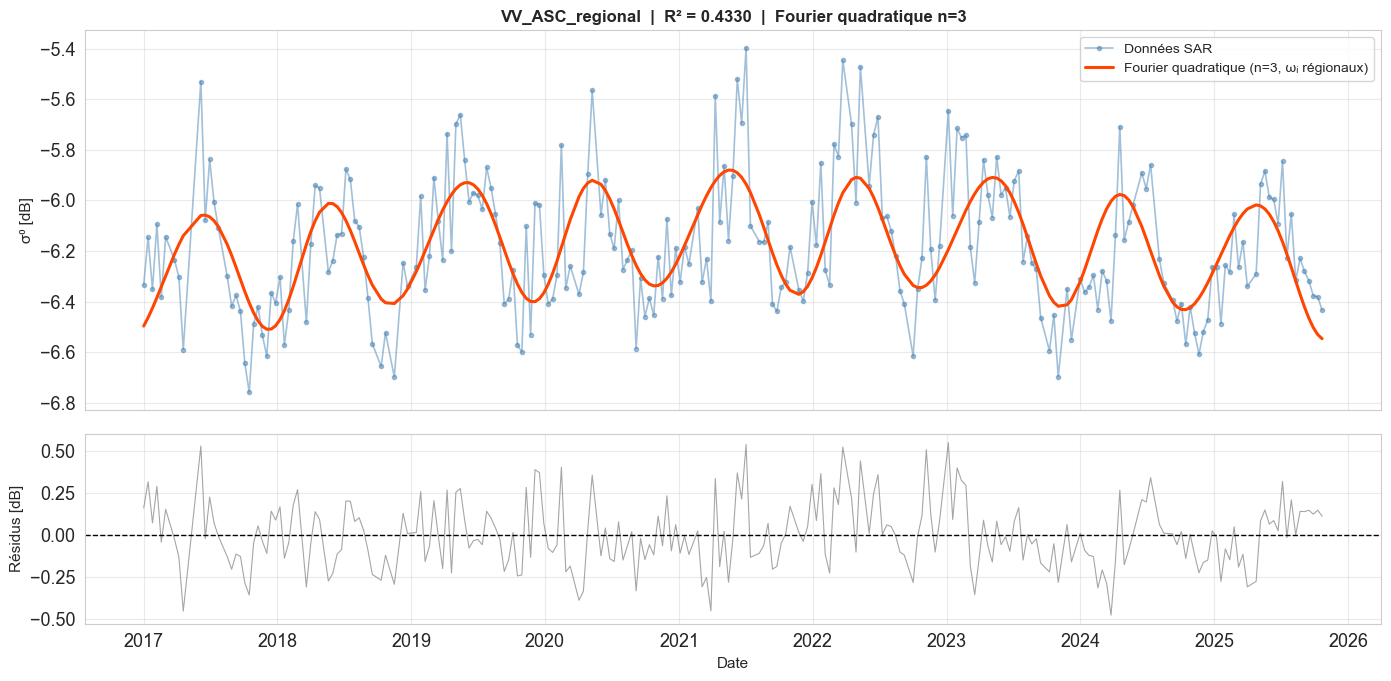

     R² = 0.4330  →  fourier_fit_VV_ASC_regional_n3.png
  → Analyse des résidus régionaux (n=3) ...


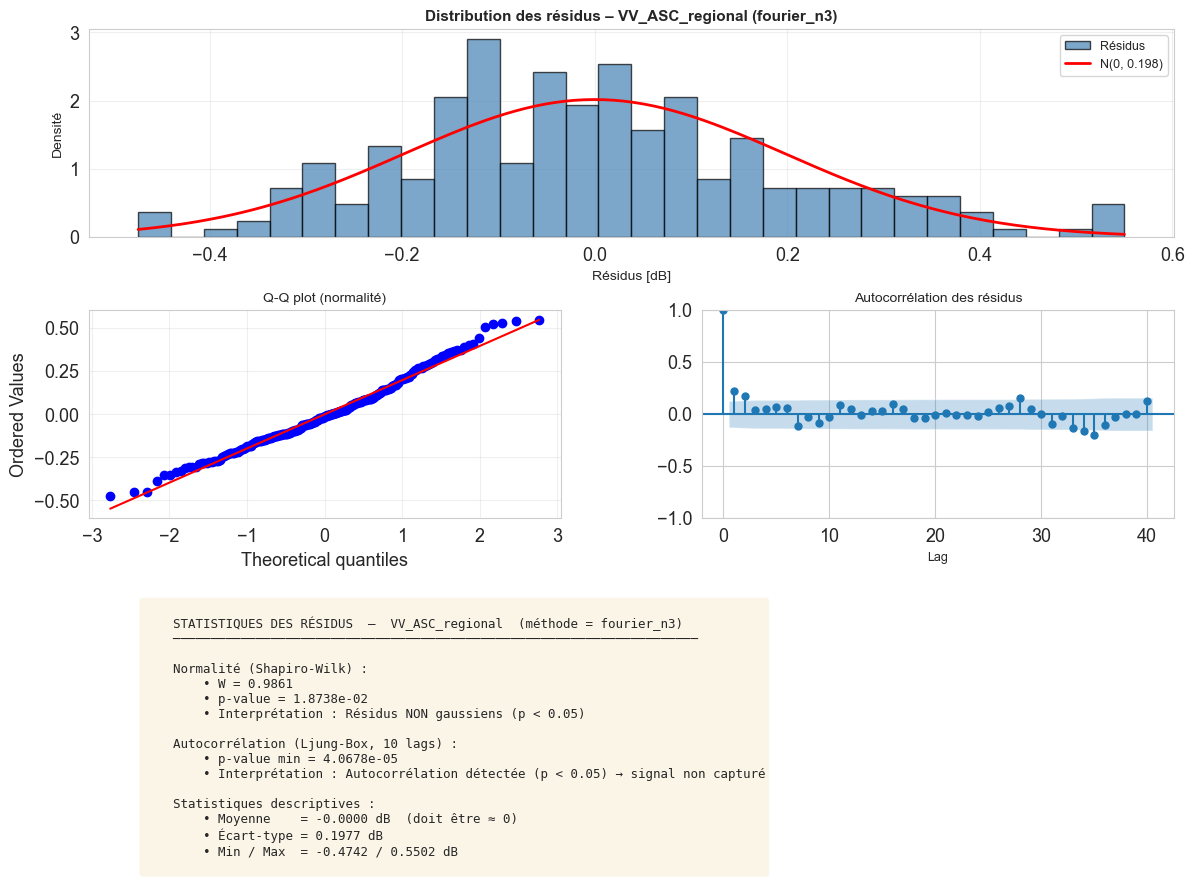

    → residuals_analysis_VV_ASC_regional_méthodefourier_n3.png
  → Ajustement local (ωᵢ régionaux fixés) ...
     Tendance : a=-5.0317, b=0.000235, c=-7.32e-08  (quadratique)


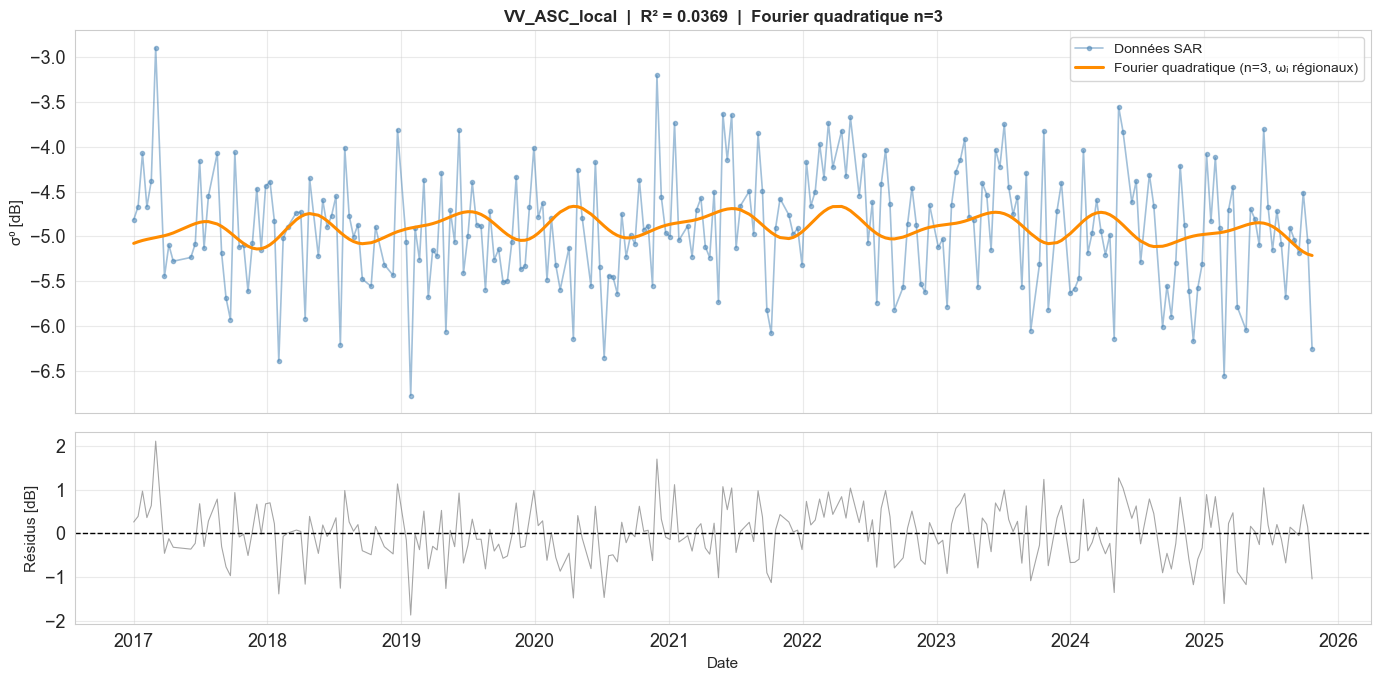

     R² = 0.0369  →  fourier_fit_VV_ASC_local_n3.png
  → Analyse des résidus locaux (n=3) ...


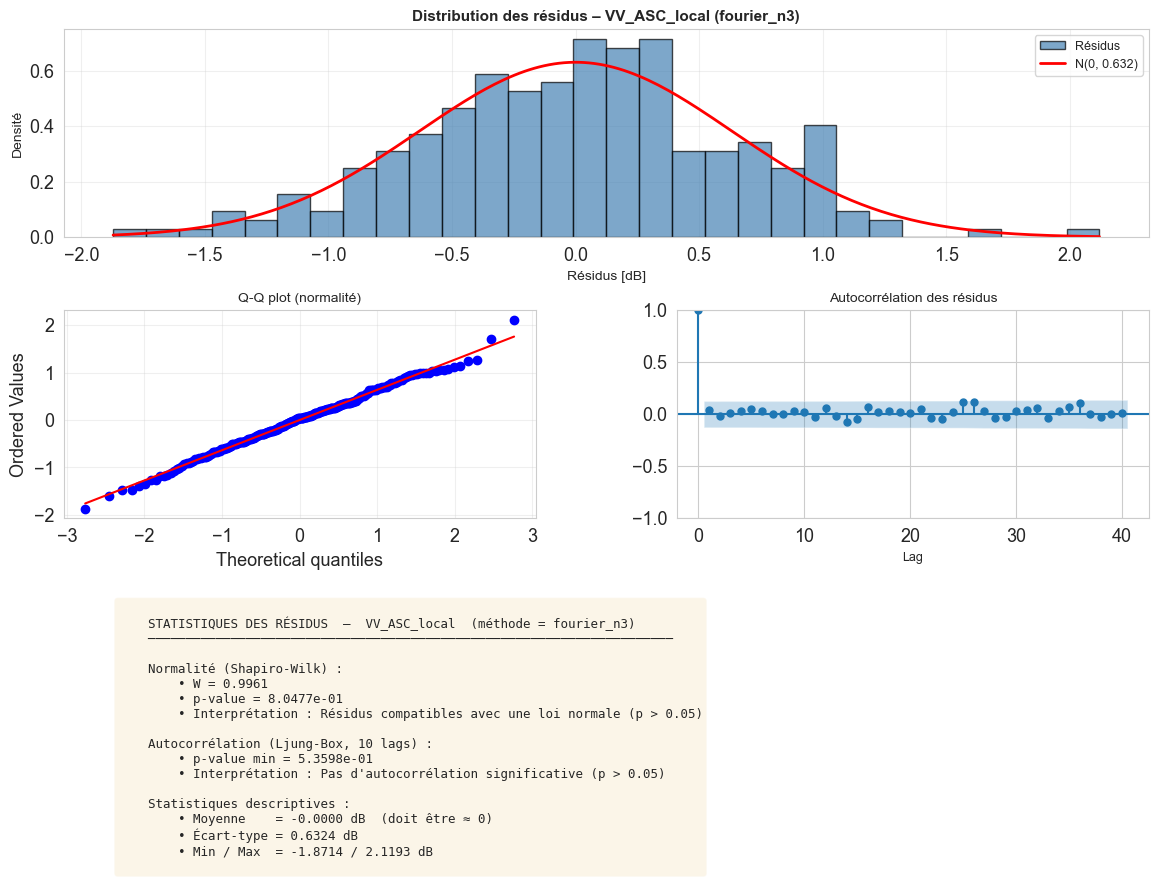

    → residuals_analysis_VV_ASC_local_méthodefourier_n3.png

  Fourier quadratique  n_freq = 4 modes
  Périodes : ['360j', '240j', '720j', '180j']
  → Ajustement régional ...
     Tendance : a=-6.3520, b=0.000273, c=-7.93e-08  (quadratique)


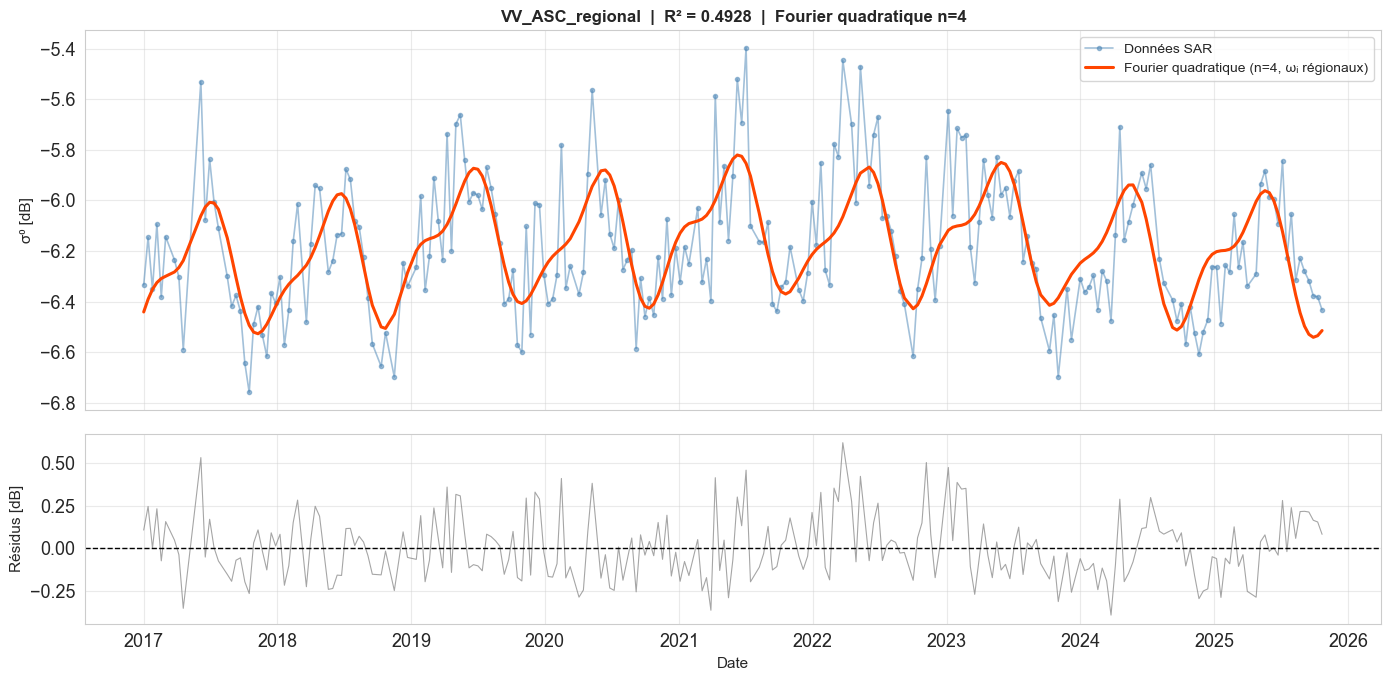

     R² = 0.4928  →  fourier_fit_VV_ASC_regional_n4.png
  → Analyse des résidus régionaux (n=4) ...


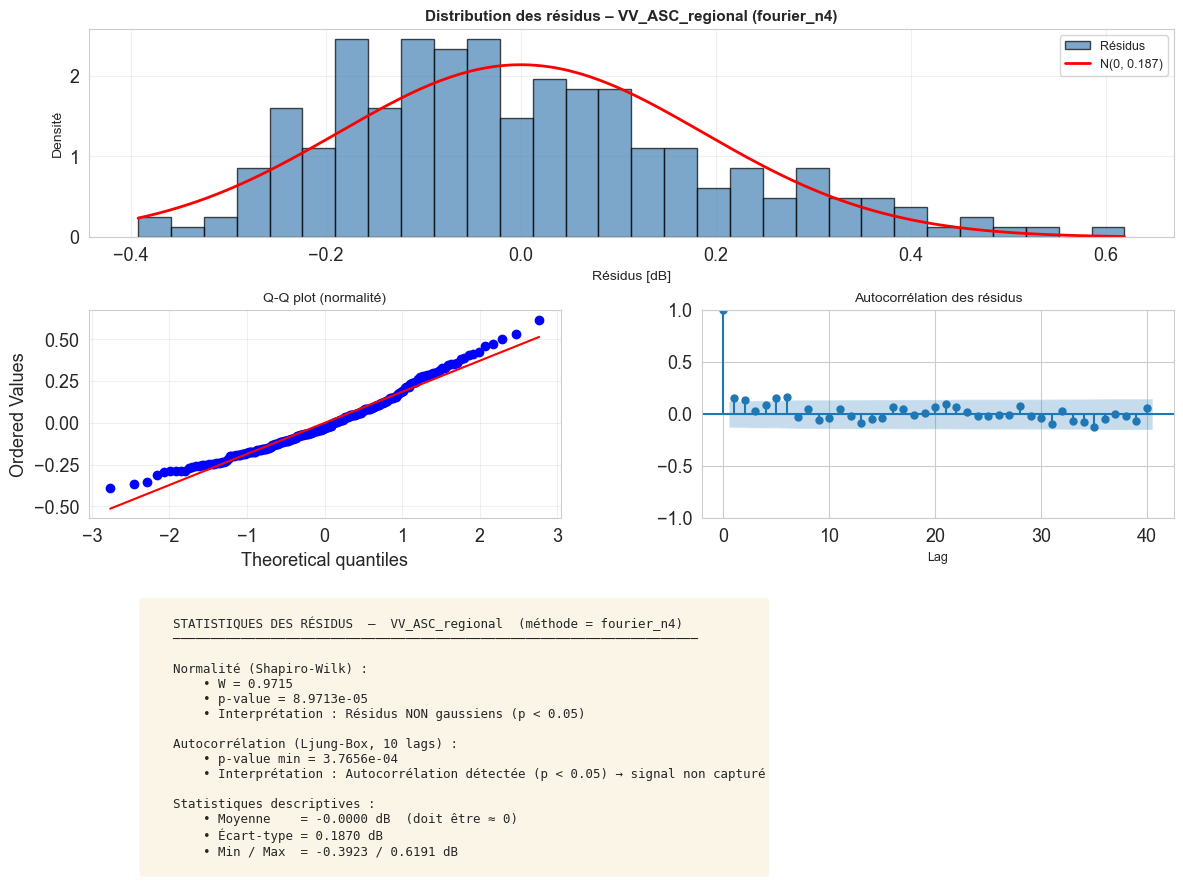

    → residuals_analysis_VV_ASC_regional_méthodefourier_n4.png
  → Ajustement local (ωᵢ régionaux fixés) ...
     Tendance : a=-5.0531, b=0.000255, c=-7.70e-08  (quadratique)


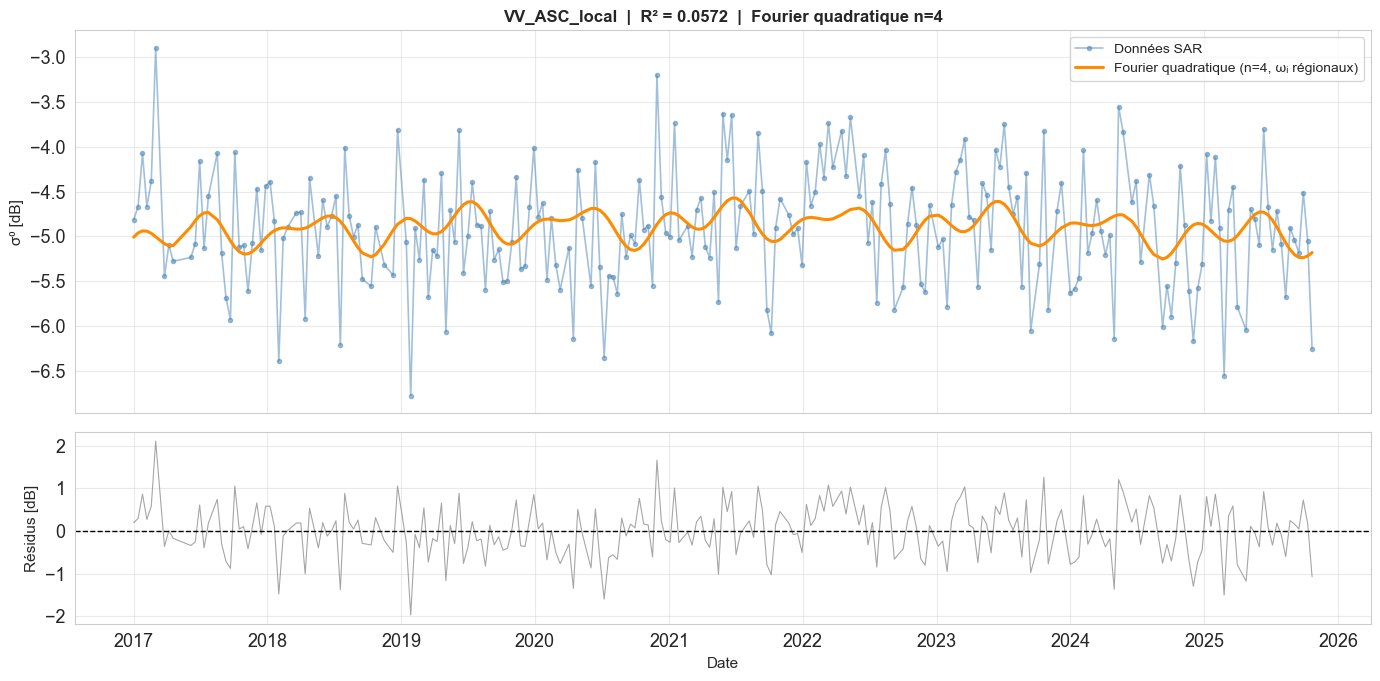

     R² = 0.0572  →  fourier_fit_VV_ASC_local_n4.png
  → Analyse des résidus locaux (n=4) ...


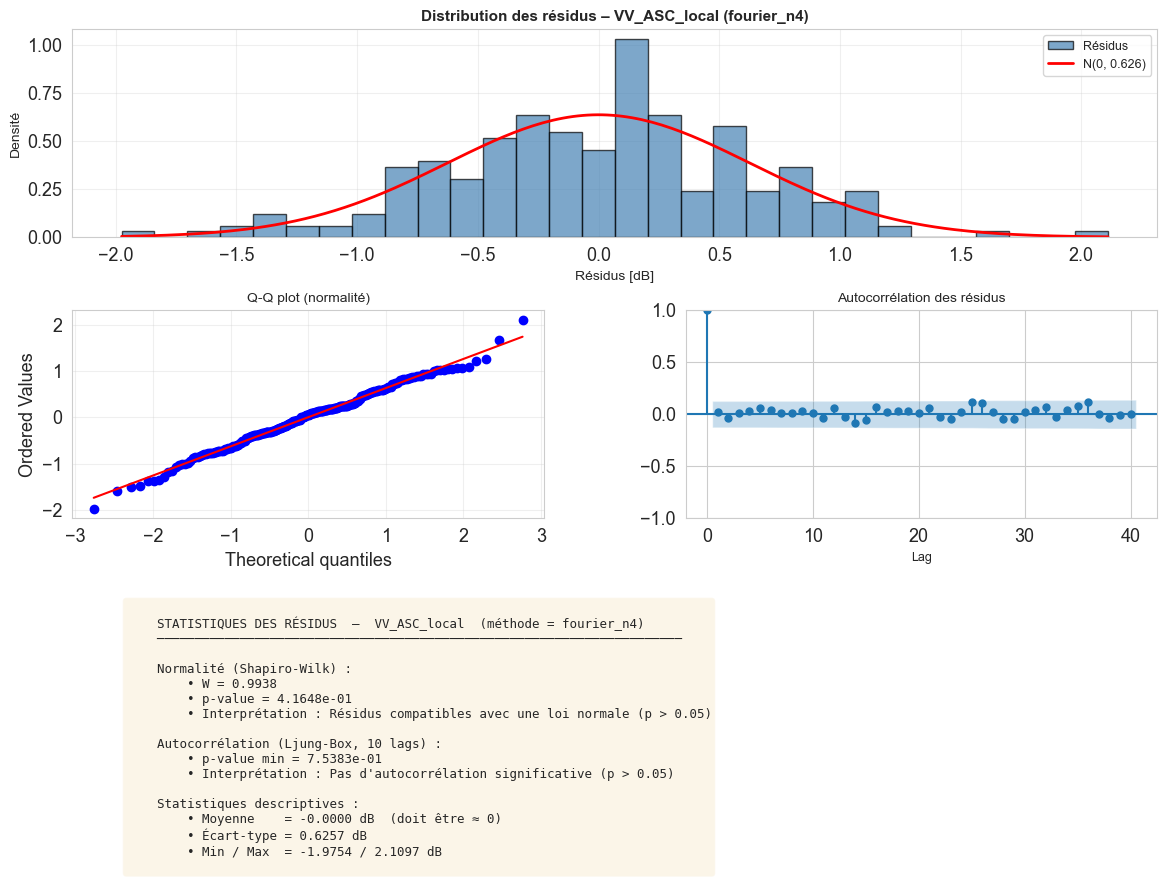

    → residuals_analysis_VV_ASC_local_méthodefourier_n4.png

✓ Boucle Fourier terminée


In [28]:
# ── Stockage des résultats pour le tableau comparatif ────────────────────────
fourier_results = []   # contiendra les métriques pour chaque (n_freq, échelle)

def make_fourier_model(omegas_fixed):
    """Closure : renvoie un modèle de Fourier avec tendance quadratique et fréquences ω figées.
    Tendance : a + b*t + c*t²
    Harmoniques : Σ [Aᵢ sin(ωᵢt) + Bᵢ cos(ωᵢt)]
    """
    def fourier_model_fixed(t, a, b, c, *coeffs):
        y = a + b * t + c * t**2          # ← tendance quadratique
        n = len(coeffs) // 2
        for i in range(n):
            A = coeffs[2 * i]
            B = coeffs[2 * i + 1]
            y += A * np.sin(omegas_fixed[i] * t) + B * np.cos(omegas_fixed[i] * t)
        return y
    return fourier_model_fixed

def fit_and_analyze_fourier(t, values, dates, omegas_fixed, n_freq,
                             label, color, outdir="figures_fourier"):
    """Ajuste le modèle de Fourier contraint (tendance quadratique) et retourne (résidus, r2, métriques)."""
    model = make_fourier_model(omegas_fixed)
    p0    = [values.mean(), 0.0, 0.0] + [0.1, 0.1] * n_freq   # ← p0 pour a, b, c, puis Aᵢ/Bᵢ
    try:
        params, _ = curve_fit(model, t, values, p0=p0, maxfev=20000)
    except RuntimeError as e:
        print(f"     ⚠ Convergence échouée ({label}) : {e}")
        return None, None, None

    y_fit     = model(t, *params)
    residuals = values - y_fit
    ss_res    = np.sum(residuals**2)
    ss_tot    = np.sum((values - values.mean())**2)
    r2        = 1 - ss_res / ss_tot

    a, b, c   = params[0], params[1], params[2]
    print(f"     Tendance : a={a:.4f}, b={b:.6f}, c={c:.2e}  (quadratique)")

    # ── Visualisation fit + résidus ──────────────────────────────────────────
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                              gridspec_kw={"height_ratios": [2, 1]})
    ax = axes[0]
    ax.plot(dates, values, "-o", lw=1.2, alpha=0.5, markersize=3,
            label="Données SAR", color="steelblue")
    ax.plot(dates, y_fit, "-", lw=2.2, color=color,
            label=f"Fourier quadratique (n={n_freq}, ωᵢ régionaux)")
    ax.set_ylabel("σ⁰ [dB]", fontsize=11)
    ax.legend(loc="best", fontsize=10)
    ax.grid(True, alpha=0.4)
    ax.set_title(f"{label}  |  R² = {r2:.4f}  |  Fourier quadratique n={n_freq}",
                 fontsize=12, fontweight="bold")
    ax = axes[1]
    ax.plot(dates, residuals, "-", lw=0.8, alpha=0.7, color="gray")
    ax.axhline(0, color="black", linestyle="--", lw=1)
    ax.set_ylabel("Résidus [dB]", fontsize=11)
    ax.set_xlabel("Date", fontsize=11)
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    fname = f"fourier_fit_{label.replace(' ', '_')}_n{n_freq}.png"
    plt.savefig(os.path.join(outdir, fname), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"     R² = {r2:.4f}  →  {fname}")

    # ── Métriques ────────────────────────────────────────────────────────────
    sw_stat, sw_p = stats.shapiro(residuals)
    lb_test       = acorr_ljungbox(residuals, lags=10, return_df=True)
    lb_p_min      = lb_test["lb_pvalue"].min()
    metrics = {
        "R²":              r2,
        "RMSE":            np.sqrt(np.mean(residuals**2)),
        "σ résidus":       residuals.std(),
        "Shapiro p":       sw_p,
        "Ljung-Box p_min": lb_p_min,
    }
    return residuals, r2, metrics


for n_freq in N_FREQ_LIST:
    print(f"\n{'='*70}")
    print(f"  Fourier quadratique  n_freq = {n_freq} modes")
    print(f"{'='*70}")

    # ── Extraction des ωᵢ sur le régional ────────────────────────────────────
    top_idx       = np.argsort(psd_w[1:])[::-1][:n_freq] + 1
    omegas_fixed  = 2 * np.pi * freqs_w[top_idx]
    periods_jours = 2 * np.pi / omegas_fixed
    print(f"  Périodes : {[f'{p:.0f}j' for p in periods_jours]}")

    # ── RÉGIONAL ─────────────────────────────────────────────────────────────
    print("  → Ajustement régional ...")
    res_f_reg, r2_f_reg, metrics_f_reg = fit_and_analyze_fourier(
        t_reg, values_reg, dates_reg, omegas_fixed, n_freq,
        label=f"{SERIES}_regional", color="orangered"
    )
    if res_f_reg is None:
        continue

    print(f"  → Analyse des résidus régionaux (n={n_freq}) ...")
    analyze_residuals(res_f_reg, f"{SERIES}_regional", method=f"fourier_n{n_freq}")
    fourier_results.append({"n_freq": n_freq, "échelle": "régionale", **metrics_f_reg})

    # ── LOCAL (mêmes ωᵢ) ─────────────────────────────────────────────────────
    print("  → Ajustement local (ωᵢ régionaux fixés) ...")
    res_f_loc, r2_f_loc, metrics_f_loc = fit_and_analyze_fourier(
        t_loc, values_loc, dates_loc, omegas_fixed, n_freq,
        label=f"{SERIES}_local", color="darkorange"
    )
    if res_f_loc is None:
        continue

    print(f"  → Analyse des résidus locaux (n={n_freq}) ...")
    analyze_residuals(res_f_loc, f"{SERIES}_local", method=f"fourier_n{n_freq}")
    fourier_results.append({"n_freq": n_freq, "échelle": "locale", **metrics_f_loc})

    # Stocker le dernier n_freq pour la comparaison finale
    if n_freq == N_FREQ_LIST[-1]:
        residuals_fourier_reg_best = res_f_reg
        residuals_fourier_loc_best = res_f_loc
        r2_fourier_reg_best        = r2_f_reg
        r2_fourier_loc_best        = r2_f_loc
        n_freq_best                = n_freq

print("\n✓ Boucle Fourier terminée")

---
## 7. Comparaison globale des résidus — Toutes méthodes

On compare côte à côte les résidus des trois méthodes, à chaque échelle.

### 7.1 Superposition temporelle des résidus

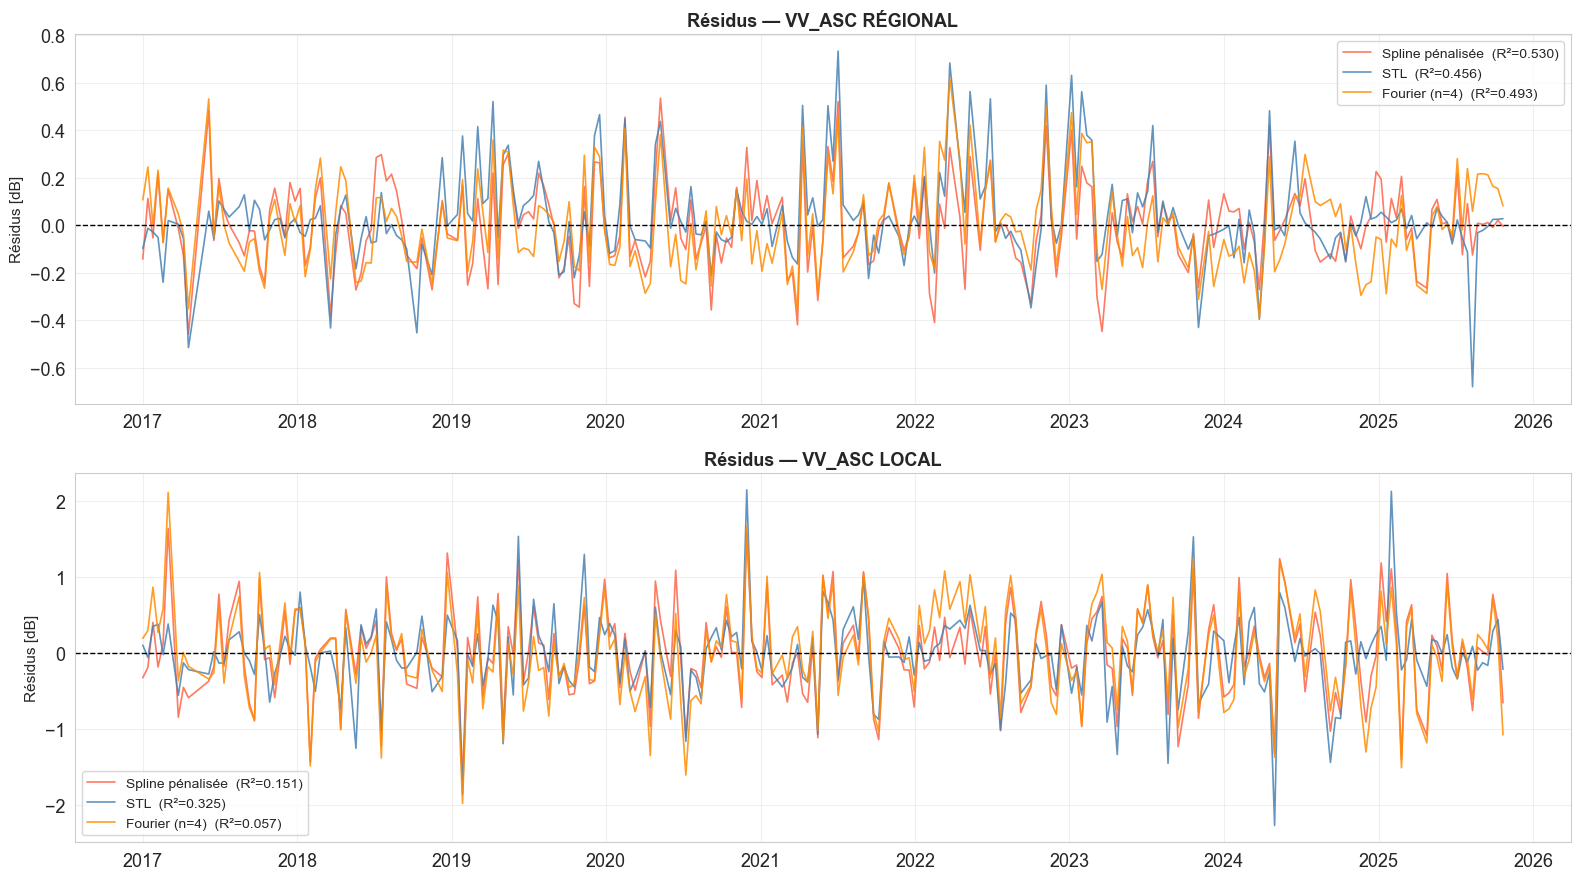

In [29]:
# ── Définition des méthodes pour la comparaison ──────────────────────────────
methods_reg = {
    "Spline pénalisée":         (residuals_spline_reg,        r2_spline_reg,        "tomato"),
    "STL":                      (residuals_stl_reg,           r2_stl_reg,           "steelblue"),
    f"Fourier (n={n_freq_best})": (residuals_fourier_reg_best, r2_fourier_reg_best, "darkorange"),
}
methods_loc = {
    "Spline pénalisée":         (residuals_spline_loc,        r2_spline_loc,        "tomato"),
    "STL":                      (residuals_stl_loc,           r2_stl_loc,           "steelblue"),
    f"Fourier (n={n_freq_best})": (residuals_fourier_loc_best, r2_fourier_loc_best, "darkorange"),
}

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=False)

for ax, (methods, dates_ax, title) in zip(
    axes,
    [(methods_reg, dates_reg, f"Résidus — {SERIES} RÉGIONAL"),
     (methods_loc, dates_loc, f"Résidus — {SERIES} LOCAL")]
):
    for label, (res, r2, color) in methods.items():
        ax.plot(dates_ax, res, lw=1.2, alpha=0.85,
                color=color, label=f"{label}  (R²={r2:.3f})")
    ax.axhline(0, color="black", linestyle="--", lw=1)
    ax.set_ylabel("Résidus [dB]", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"figures_residuals/comparaison_temporelle_{SERIES}.png",
            dpi=150, bbox_inches="tight")
plt.show()

### 7.2 Distributions comparées

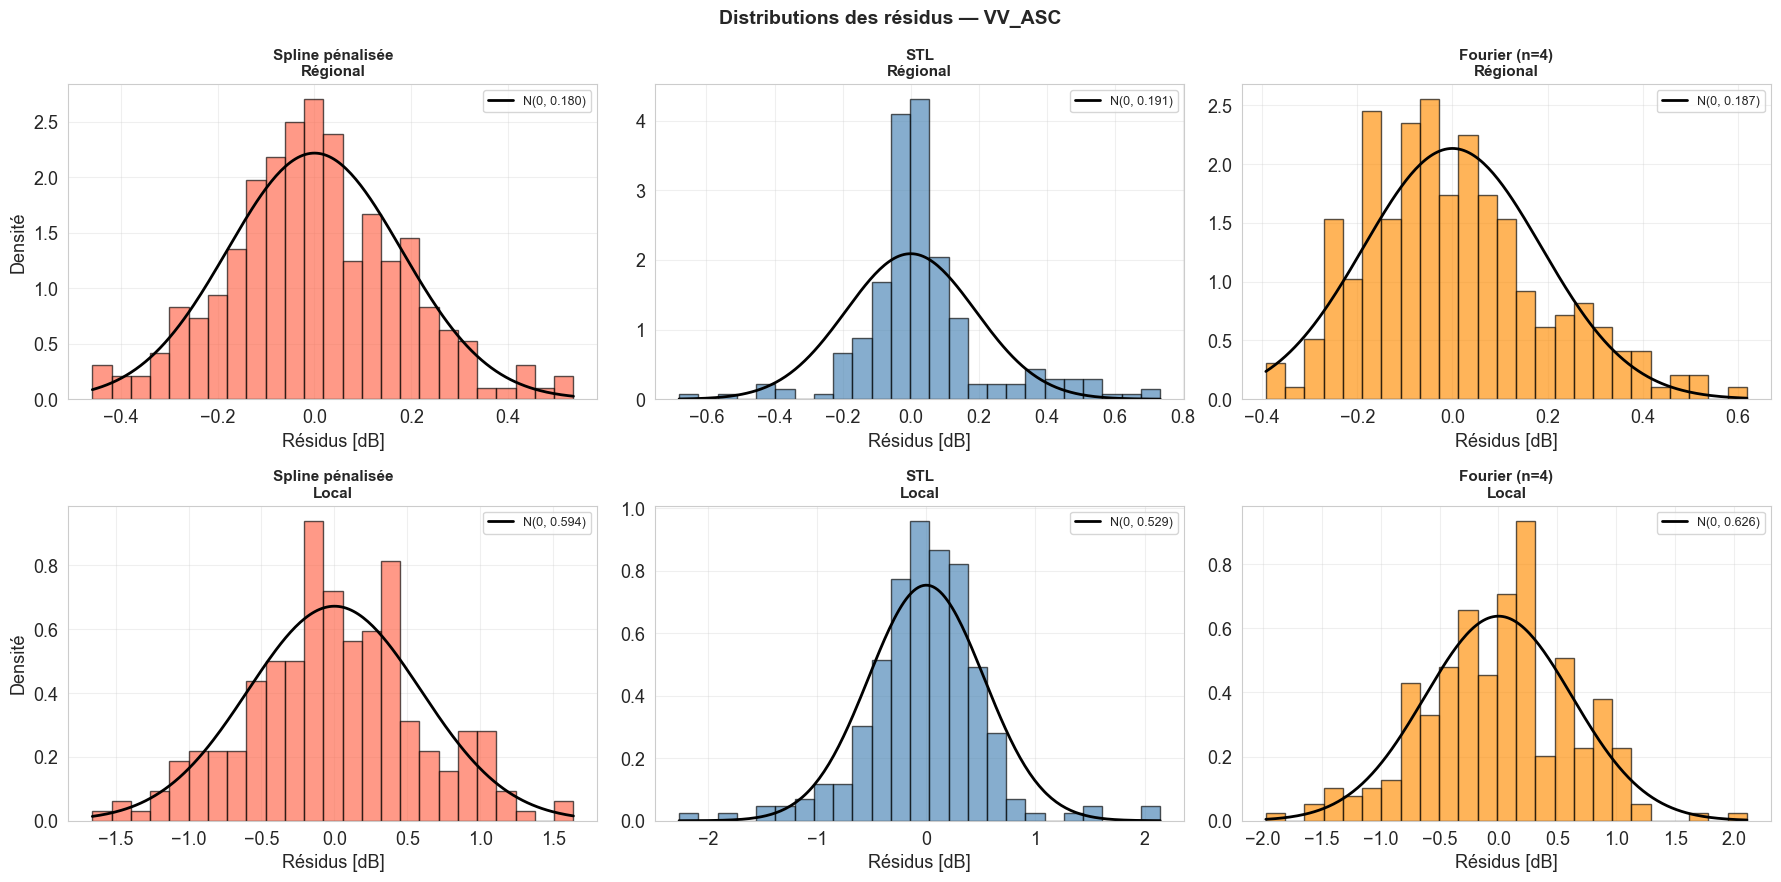

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for row, (methods, scale) in enumerate([
    (methods_reg, "Régional"),
    (methods_loc, "Local")
]):
    for col, (label, (res, r2, color)) in enumerate(methods.items()):
        ax = axes[row, col]
        ax.hist(res, bins=25, density=True, alpha=0.65,
                color=color, edgecolor="black")
        x_range = np.linspace(res.min(), res.max(), 200)
        ax.plot(x_range, stats.norm.pdf(x_range, 0, res.std()),
                "k-", lw=2, label=f"N(0, {res.std():.3f})")
        ax.set_title(f"{label}\n{scale}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Résidus [dB]")
        ax.set_ylabel("Densité" if col == 0 else "")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.suptitle(f"Distributions des résidus — {SERIES}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"figures_residuals/distributions_{SERIES}.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.3 Q-Q plots comparés

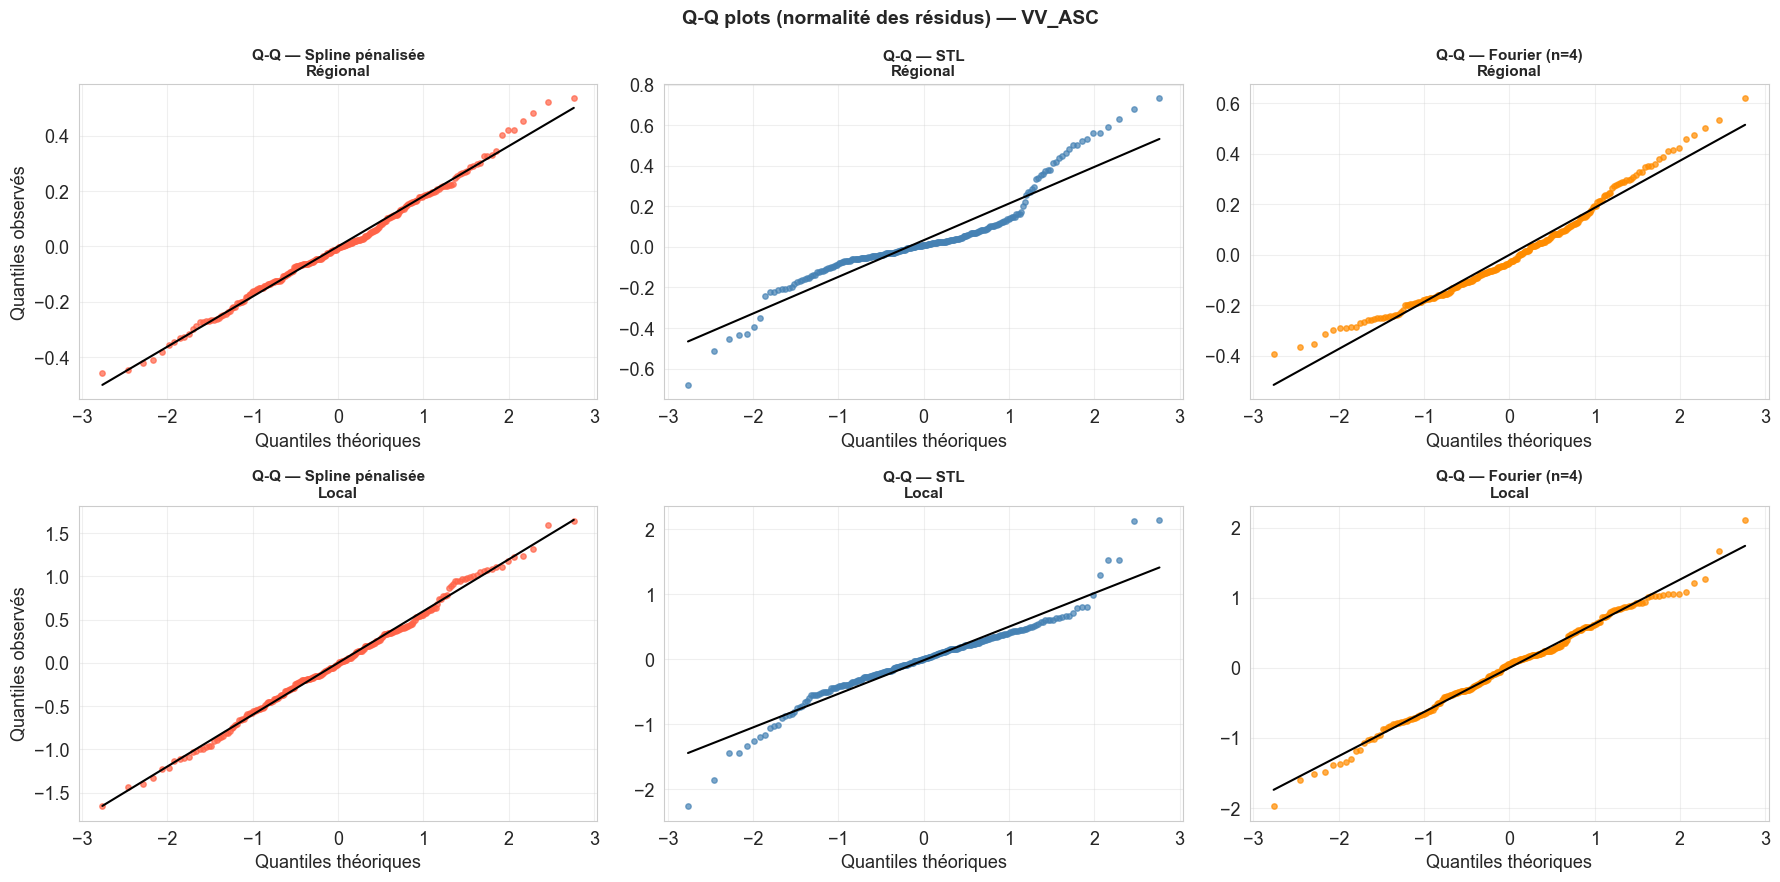

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for row, (methods, scale) in enumerate([
    (methods_reg, "Régional"),
    (methods_loc, "Local")
]):
    for col, (label, (res, r2, color)) in enumerate(methods.items()):
        ax = axes[row, col]
        (osm, osr), (slope, intercept, _) = stats.probplot(res, dist="norm")
        ax.scatter(osm, osr, color=color, s=15, alpha=0.7)
        ax.plot(osm, slope * np.array(osm) + intercept, "k-", lw=1.5)
        ax.set_title(f"Q-Q — {label}\n{scale}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Quantiles théoriques")
        ax.set_ylabel("Quantiles observés" if col == 0 else "")
        ax.grid(True, alpha=0.3)

plt.suptitle(f"Q-Q plots (normalité des résidus) — {SERIES}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"figures_residuals/qqplots_{SERIES}.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.4 Autocorrélations comparées (ACF)

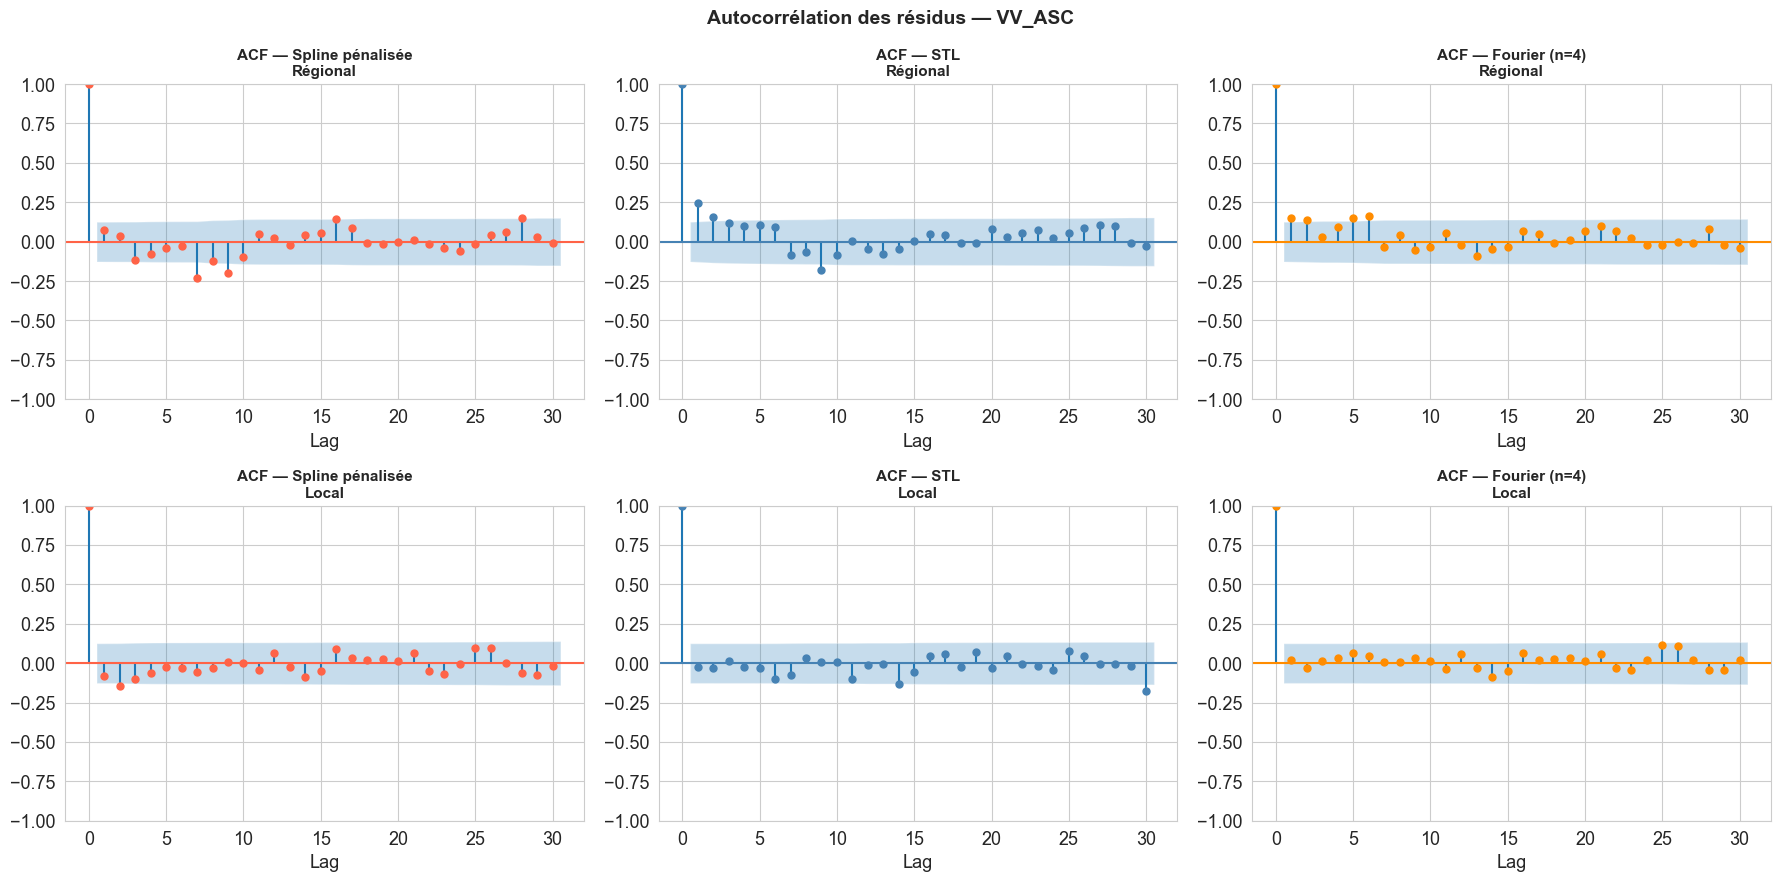

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for row, (methods, scale) in enumerate([
    (methods_reg, "Régional"),
    (methods_loc, "Local")
]):
    for col, (label, (res, r2, color)) in enumerate(methods.items()):
        ax = axes[row, col]
        plot_acf(res, lags=min(30, len(res) // 2), ax=ax, alpha=0.05, color=color)
        ax.set_title(f"ACF — {label}\n{scale}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Lag")

plt.suptitle(f"Autocorrélation des résidus — {SERIES}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"figures_residuals/acf_{SERIES}.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Tableau récapitulatif des indicateurs de qualité

In [33]:
# ── Construction du tableau complet ──────────────────────────────────────────
rows = []

all_combinations = [
    ("Spline pénalisée", "régionale", residuals_spline_reg, r2_spline_reg),
    ("Spline pénalisée", "locale",    residuals_spline_loc, r2_spline_loc),
    ("STL",              "régionale", residuals_stl_reg,    r2_stl_reg),
    ("STL",              "locale",    residuals_stl_loc,    r2_stl_loc),
    (f"Fourier n={n_freq_best}", "régionale", residuals_fourier_reg_best, r2_fourier_reg_best),
    (f"Fourier n={n_freq_best}", "locale",    residuals_fourier_loc_best, r2_fourier_loc_best),
]

for method, scale, res, r2 in all_combinations:
    sw_stat, sw_p = stats.shapiro(res)
    lb_test       = acorr_ljungbox(res, lags=10, return_df=True)
    lb_p_min      = lb_test["lb_pvalue"].min()
    rows.append({
        "Méthode":              method,
        "Échelle":              scale,
        "R²":                   f"{r2:.4f}",
        "RMSE [dB]":            f"{np.sqrt(np.mean(res**2)):.4f}",
        "σ résidus [dB]":       f"{res.std():.4f}",
        "Moyenne résidus [dB]": f"{res.mean():.5f}",
        "Shapiro W":            f"{sw_stat:.4f}",
        "Shapiro p":            f"{sw_p:.2e}",
        "Ljung-Box p_min":      f"{lb_p_min:.2e}",
        "Gaussien (p>0.05)":    "✓" if sw_p    > 0.05 else "✗",
        "Bruit blanc (p>0.05)": "✓" if lb_p_min > 0.05 else "✗",
    })

df_summary = pd.DataFrame(rows)
print(f"\n{'='*90}")
print(f"TABLEAU RÉCAPITULATIF — Série : {SERIES}")
print(f"{'='*90}")
display(df_summary.set_index(["Méthode", "Échelle"]))

# Export CSV
csv_path = f"figures_residuals/recap_{SERIES}.csv"
df_summary.to_csv(csv_path, index=False)
print(f"\n✓ Tableau sauvegardé : {csv_path}")


TABLEAU RÉCAPITULATIF — Série : VV_ASC


R² RMSE [dB] σ résidus [dB]  \
Méthode          Échelle                                      
Spline pénalisée régionale  0.5303    0.1800         0.1800   
                 locale     0.1512    0.5937         0.5937   
STL              régionale  0.4556    0.1937         0.1909   
                 locale     0.3250    0.5294         0.5292   
Fourier n=4      régionale  0.4928    0.1870         0.1870   
                 locale     0.0572    0.6257         0.6257   

                           Moyenne résidus [dB] Shapiro W Shapiro p  \
Méthode          Échelle                                              
Spline pénalisée régionale              0.00000    0.9930  3.14e-01   
                 locale                -0.00000    0.9959  7.79e-01   
STL              régionale              0.03329    0.8845  1.29e-12   
                 locale                -0.01641    0.9412  2.76e-08   
Fourier n=4      régionale             -0.00000    0.9715  8.97e-05   
                 locale                -0.00000    0.9938  4.16e-01   

                           Ljung-Box p_min Gaussien (p>0.05)  \
Méthode          Échelle                                       
Spline pénalisée régionale        5.72e-05                 ✓   
                 locale           2.64e-02                 ✓   
STL              régionale        2.64e-06                 ✗   
                 locale           6.99e-01                 ✗   
Fourier n=4      régionale        3.77e-04                 ✗   
                 locale           7.54e-01                 ✓   

                           Bruit blanc (p>0.05)  
Méthode          Échelle                         
Spline pénalisée régionale                    ✗  
                 locale                       ✗  
STL              régionale                    ✗  
                 locale                       ✓  
Fourier n=4      régionale                    ✗  
                 locale                       ✓


✓ Tableau sauvegardé : figures_residuals/recap_VV_ASC.csv


### Tableau Fourier — comparaison des modes

In [34]:
# Tableau détaillé Fourier (tous les modes)
df_fourier = pd.DataFrame(fourier_results)
df_fourier["R²"]          = df_fourier["R²"].map("{:.4f}".format)
df_fourier["RMSE"]        = df_fourier["RMSE"].map("{:.4f}".format)
df_fourier["σ résidus"]   = df_fourier["σ résidus"].map("{:.4f}".format)
df_fourier["Shapiro p"]   = df_fourier["Shapiro p"].map("{:.2e}".format)
df_fourier["Ljung-Box p_min"] = df_fourier["Ljung-Box p_min"].map("{:.2e}".format)

print("\nRésultats Fourier — tous les modes :")
display(df_fourier.set_index(["n_freq", "échelle"]))


Résultats Fourier — tous les modes :


R²    RMSE σ résidus Shapiro p Ljung-Box p_min
n_freq échelle                                                      
2      régionale  0.4239  0.1993    0.1993  4.21e-02        1.15e-05
       locale     0.0354  0.6329    0.6329  7.86e-01        5.17e-01
3      régionale  0.4330  0.1977    0.1977  1.87e-02        4.07e-05
       locale     0.0369  0.6324    0.6324  8.05e-01        5.36e-01
4      régionale  0.4928  0.1870    0.1870  8.97e-05        3.77e-04
       locale     0.0572  0.6257    0.6257  4.16e-01        7.54e-01

---
## 9. Conclusions

### Lecture des indicateurs

| Indicateur | Interprétation |
|---|---|
| **R² élevé** | Le modèle explique bien la variance du signal |
| **RMSE faible** | Erreur quadratique moyenne faible |
| **Shapiro-Wilk p > 0.05** | Résidus gaussiens → hypothèse bruit blanc validée |
| **Ljung-Box p > 0.05** | Pas d'autocorrélation résiduelle → la structure temporelle est bien capturée |
| **Moyenne résidus ≈ 0** | Absence de biais systématique |

### Comparaison des méthodes

| Méthode | Forces | Limites |
|---|---|---|
| **Spline pénalisée** | Flexible, λ transféré régional→local contrôle le sur-ajustement, sélection n_knots rigoureuse (Mallows Cₚ) | Pas de structure périodique explicite, moins interprétable physiquement |
| **STL** | Robuste aux valeurs aberrantes (robust=True), décomposition Trend/Seasonal claire, peu de paramètres | Période saisonnière fixée manuellement, pas de transfert régional→local |
| **Fourier contraint** | Fréquences extraites sur le régional → contrainte physique forte, interprétation harmonique directe | Hypothèse de stationnarité, sensible au choix de n_freq, peut sur-ajuster si n grand |

### Prochaines étapes
1. Appliquer l'analyse sur les 4 séries (`VV_ASC`, `VH_ASC`, `VV_DSC`, `VH_DSC`)
2. Corréler les pics de résidus avec les données météo (VPD, précipitations) pour détecter la défoliation
3. Quantifier l'anomalie locale = écart entre la série locale et la prédiction contrainte par le régional